<img src="https://images.seeklogo.com/logo-png/28/1/u-cayetano-heredia-logo-png_seeklogo-289967.png" alt="LOGO UPCH" width=250 align="right">

<br>
<h1><font color="#7F000E" size=5>UNIVERSIDAD PERUANA CAYETANO HEREDIA</font></h1>
<h1><font color="#7F000E" size=6>SEÑALES BIOMÉDICAS</font></h1>
<h1><font color="#7F000E" size=4>LAB 7 — Filtrado de señales II: Filtros adaptativos y Transformada Wavelet</font></h1>
<br>
<br>
<div style="text-align:right">
<!--<font color="#7F000E" size=3> Ing. Alexander Valdez Portocarrero</font><br>-->

<font color="#7F000E" size=3> Curso: Introducción a las Señales Biomédicas </font><br>
<font color="#7F000E" size=3> Modalidad: Jupyter Notebook / Google Colab </font><br>
<font color="#7F000E" size=3> Tema: Filtrado de señales II — Filtros adaptativos (LMS) y Transformada Wavelet aplicados a ECG </font><br>
<font color="#7F000E" size=3> Laboratorio práctico · Duración: 2 horas (120 min) </font><br>
</div>

| Campo | Completar |
|---|---|
| **Nombre del estudiante** | ✍️ |
| **Código** | ✍️ |
| **Fecha** | ✍️ |

---

> **Enfoque del laboratorio:** *"Primero observamos la señal, luego la contaminamos, analizamos cómo se degrada, aplicamos diferentes técnicas de filtrado y finalmente evaluamos qué ocurrió con la señal."*

## 🎯 Resultados de aprendizaje

Al finalizar el laboratorio, serás capaz de:

1. Identificar una señal ECG en datos adquiridos mediante **BITalino (r)evolution / OpenSignals**.
2. Diferenciar **señal fisiológica**, **interferencia** y **ruido**.
3. Generar artificialmente señales contaminadas de forma controlada.
4. Aplicar filtros digitales (pasa-banda y notch).
5. Comparar métodos de filtrado con criterios visuales y cuantitativos.
6. Comprender conceptualmente el **filtrado adaptativo** (algoritmo LMS).
7. Comprender para qué sirve la **Transformada Wavelet**.
8. Evaluar la recuperación de una señal ECG.
9. Comunicar los resultados mediante una **infografía**.

## ⏱️ Agenda de la sesión (120 min)

| Bloque | Contenido | Duración | Minutos |
|---|---|---:|---:|
| 1 | Introducción y exploración de datos | 15 min | 0 – 15 |
| 2 | Señal ECG original | 15 min | 15 – 30 |
| 3 | Contaminación artificial + análisis en frecuencia | 20 min | 30 – 50 |
| 4 | Aplicación de filtros convencionales + métricas | 25 min | 50 – 75 |
| 5 | Filtros adaptativos y Wavelet | 20 min | 75 – 95 |
| 6 | Comparación e interpretación | 10 min | 95 – 105 |
| 7 | Retroalimentación, síntesis e infografía | 15 min | 105 – 120 |

> 🔁 **Los últimos 30 minutos (min 90 – 120)** se dedican a **revisión, discusión y retroalimentación**: cierre de la discusión Wavelet, comparación global (Bloque 6), preguntas, síntesis *SUMARIZE* e infografía (Bloque 7). En este tramo **no se introducen conceptos nuevos**.

**Patrón de trabajo en cada sección:**

```text
CONCEPTO → EXPLICACIÓN BREVE → CÓDIGO → GRÁFICA → INTERPRETACIÓN → PREGUNTA AL ESTUDIANTE
```

---
# 🟦 BLOQUE 1 — Introducción y exploración de datos *(15 min)*

## 1.1 Librerías

| Librería | Para qué la usamos |
|---|---|
| `numpy` | Operaciones numéricas con vectores: eje temporal, senoides, ruido, FFT. |
| `pandas` | Leer el archivo de texto como tabla y explorar columnas/estadísticas. |
| `matplotlib` | Graficar señales en tiempo y frecuencia. |
| `scipy.signal` | Diseñar y aplicar filtros digitales (`butter`, `iirnotch`, `filtfilt`, `freqz`). |
| `pywt` (PyWavelets) | Transformada Wavelet discreta: descomposición y *denoising*. |

In [29]:
# Si trabajas en Google Colab y PyWavelets no está instalado, descomenta la siguiente línea:
# !pip install PyWavelets

import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import signal
import pywt

# Estilo de gráficos uniforme para todo el laboratorio
plt.rcParams.update({
    "figure.figsize": (14, 4),
    "axes.grid": True,
    "grid.alpha": 0.3,
    "axes.titleweight": "bold",
    "font.size": 11,
})

# Semilla: garantiza que el ruido "aleatorio" sea el mismo en cada ejecución (reproducibilidad)
rng = np.random.default_rng(seed=42)

print("NumPy:", np.__version__, "| Pandas:", pd.__version__, "| PyWavelets:", pywt.__version__)

NumPy: 2.1.3 | Pandas: 2.2.3 | PyWavelets: 1.8.0


## 1.2 El archivo `SampleECG.txt` (formato OpenSignals)

Un archivo exportado por **OpenSignals** tiene dos partes:

1. **Cabecera**: líneas que comienzan con `#`. Una de ellas contiene un diccionario JSON con los metadatos de adquisición (frecuencia de muestreo, resolución, nombres de columnas, etc.).
2. **Datos**: una fila por muestra, con columnas separadas por tabulaciones.

| Columna | Significado | ¿Es ECG? |
|---|---|---|
| `nSeq` | Contador de secuencia de paquetes | ❌ |
| `I1`, `I2` | Entradas digitales | ❌ |
| `O1`, `O2` | Salidas digitales | ❌ |
| `A2` | Canal analógico con el sensor ECG | ✅ |

Primero aseguramos que el archivo esté disponible (en Colab se puede subir desde la computadora).

In [30]:
RUTA_ARCHIVO = "ACTIV.AEROBICA D1.txt"

if not os.path.exists(RUTA_ARCHIVO):
    try:
        from google.colab import files   # Solo existe en Google Colab
        print("Selecciona el archivo ACTIV.AEROBICA D1.txt desde tu computadora...")
        files.upload()
    except ImportError:
        print(f"⚠️ No se encontró '{RUTA_ARCHIVO}'. Colócalo en la misma carpeta que este notebook.")

print("¿Archivo disponible?:", os.path.exists(RUTA_ARCHIVO))

¿Archivo disponible?: True


### Leer la cabecera

Leemos solo las líneas iniciales que empiezan con `#` y extraemos los metadatos **directamente del archivo** (no los suponemos).

In [31]:
# 1) Guardar las líneas de cabecera (empiezan con '#')
lineas_cabecera = []
with open(RUTA_ARCHIVO, "r", encoding="utf-8", errors="ignore") as archivo:
    for linea in archivo:
        if linea.startswith("#"):
            lineas_cabecera.append(linea.strip())
        else:
            break  # termina la cabecera, empiezan los datos

print("Cabecera del archivo:\n")
for linea in lineas_cabecera:
    print(linea[:300] + ("..." if len(linea) > 300 else ""))

# 2) Buscar la línea JSON con los metadatos del dispositivo
metadatos = {}
for linea in lineas_cabecera:
    contenido = linea.lstrip("#").strip()
    if contenido.startswith("{"):
        try:
            diccionario = json.loads(contenido)
            metadatos = list(diccionario.values())[0]   # primer dispositivo (identificado por su MAC)
        except json.JSONDecodeError:
            print("No se pudo interpretar el JSON de la cabecera.")

# 3) Extraer los parámetros relevantes (con valores por defecto si faltaran)
Fs = int(metadatos.get("sampling rate", 1000))
columnas = metadatos.get("column", ["nSeq", "I1", "I2", "O1", "O2", "A2"])
resoluciones = metadatos.get("resolution", [])
resolucion_A2 = resoluciones[columnas.index("A2")] if len(resoluciones) == len(columnas) else 10

print("\nFrecuencia de muestreo (Fs):", Fs, "Hz")
print("Columnas:", columnas)
print("Resolución del canal A2:", resolucion_A2, "bits")

Cabecera del archivo:

# OpenSignals Text File Format. Version 1
# {"B4:E3:F9:E4:D1:41": {"position": 0, "device": "bitalino_rev", "device name": "B4:E3:F9:E4:D1:41", "device connection": "BTHB4:E3:F9:E4:D1:41", "sampling rate": 1000, "resolution": [4, 1, 1, 1, 1, 10], "firmware version": 1282, "comments": "", "keywords": "", "mode": 0, "sync interval": 2, "date"...
# EndOfHeader

Frecuencia de muestreo (Fs): 1000 Hz
Columnas: ['nSeq', 'I1', 'I2', 'O1', 'O2', 'A2']
Resolución del canal A2: 10 bits


### Leer los datos

In [32]:
# comment="#" ignora la cabecera; sep=r"\s+" admite tabulaciones (y tabulaciones finales)
datos = pd.read_csv(RUTA_ARCHIVO, sep=r"\s+", comment="#", header=None)
datos = datos.iloc[:, :len(columnas)]   # nos quedamos solo con las columnas declaradas
datos.columns = columnas

numero_muestras = len(datos)
Ts = 1 / Fs                              # periodo de muestreo
duracion_total = numero_muestras / Fs

print(f"Número de muestras : {numero_muestras}")
print(f"Frecuencia muestreo: {Fs} Hz")
print(f"Periodo de muestreo: {Ts*1000:.1f} ms")
print(f"Duración total     : {duracion_total:.2f} s")
print(f"Columnas           : {list(datos.columns)}")
datos.head(10)

Número de muestras : 92850
Frecuencia muestreo: 1000 Hz
Periodo de muestreo: 1.0 ms
Duración total     : 92.85 s
Columnas           : ['nSeq', 'I1', 'I2', 'O1', 'O2', 'A2']


,nSeq,I1,I2,O1,O2,A2
0,0,0,0,0,0,491
1,1,0,0,0,0,492
2,2,0,0,0,0,494
3,3,0,0,0,0,494
4,4,0,0,0,0,494
5,5,0,0,0,0,495
6,6,0,0,0,0,494
7,7,0,0,0,0,494
8,8,0,0,0,0,493
9,9,0,0,0,0,492


In [33]:
# Estadísticas básicas de todas las columnas
datos.describe().T

,count,mean,std,min,25%,50%,75%,max
nSeq,92850.0,7.499849,4.609862,0.0,3.0,7.0,11.0,15.0
I1,92850.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0
I2,92850.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0
O1,92850.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0
O2,92850.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0
A2,92850.0,505.744599,35.002751,310.0,483.0,503.0,526.0,696.0


### ¿Por qué **no** usar `nSeq` como eje temporal?

`nSeq` es un **contador de paquetes** que se reinicia periódicamente (en BITalino es un contador de 4 bits: 0, 1, …, 15, 0, 1, …). Sirve para **detectar muestras perdidas** durante la transmisión, pero **no** es el tiempo absoluto. El eje temporal correcto se construye a partir del índice de muestra y la frecuencia de muestreo:

$$t[n] = \frac{n}{F_s}$$

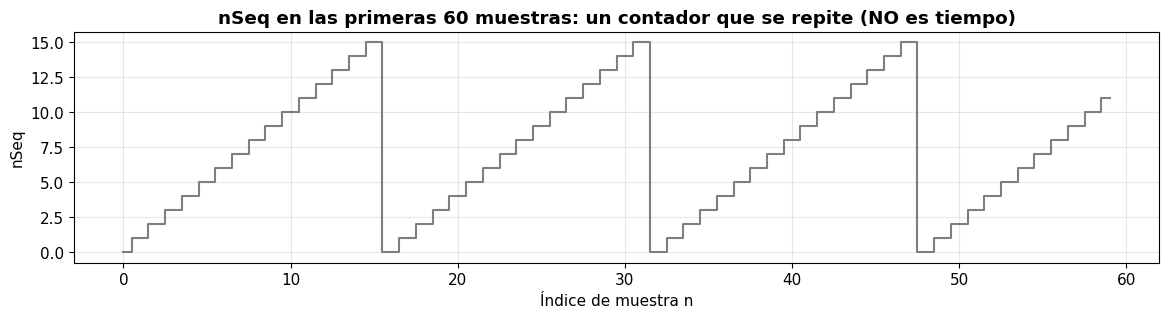

El contador va de 0 a 15.
Muestras con salto distinto de 1 (posibles pérdidas): 0


In [34]:
fig, ax = plt.subplots(figsize=(14, 3))
ax.step(np.arange(60), datos["nSeq"].values[:60], where="mid", color="tab:gray")
ax.set_title("nSeq en las primeras 60 muestras: un contador que se repite (NO es tiempo)")
ax.set_xlabel("Índice de muestra n"); ax.set_ylabel("nSeq")
plt.show()

# Verificación de paquetes perdidos: el salto esperado entre muestras consecutivas es 1 (módulo del contador)
modulo = int(datos["nSeq"].max()) + 1
saltos = np.diff(datos["nSeq"].values) % modulo
print(f"El contador va de 0 a {modulo-1}.")
print("Muestras con salto distinto de 1 (posibles pérdidas):", int(np.sum(saltos != 1)))

### ❓ Pregunta al estudiante (Bloque 1)
Según la cabecera, ¿cuántos niveles distintos puede tomar el canal `A2`? (Pista: $2^{\text{bits}}$). ¿Por qué es útil verificar `nSeq` antes de analizar la señal?

✍️ **Respuesta:**
A2 tiene una resolucion de 10 bits, por lo que puede tomar 2^10 = 1024 niveles digitales diferentes, desde 0 hasta 1023. Dicha resolución determina cuantos valores discretos puede utilizar el ADC para representar la amplitud de la señal, Por otro lado, verificar nSeq permite comprobar la continuidad de la adquisicion. Si los numeros de secuencia no son consecutivos, puede indicar pérdida de muestras, lo cual podría afectar la construcción del eje temportal y los análisis posteriores de la señal.

---
# 🟦 BLOQUE 2 — Señal ECG original *(15 min)*

## 2.1 Conceptos mínimos

- **Amplitud**: magnitud de la señal (aquí, en mV).
- **Tiempo**: eje horizontal construido con $t = n/F_s$.
- **Frecuencia de muestreo** $F_s$: muestras por segundo (1000 Hz → 1000 muestras/s).
- **Periodo de muestreo** $T_s = 1/F_s$: tiempo entre muestras (1 ms).
- **Morfología ECG**: forma característica de cada latido (onda P, complejo QRS, onda T).
- **Ruido**: componente aleatoria, no deseada, generalmente de banda ancha.
- **Interferencia**: componente no deseada con origen y estructura identificables (p. ej., la red eléctrica a una frecuencia fija).

## 2.2 Extraer `A2` y convertir a milivoltios

El canal `A2` contiene valores del conversor analógico-digital (ADC). Para expresarlos en mV usamos la función de transferencia del sensor ECG de BITalino (hoja de datos del fabricante):

$$ECG_{mV} = \left(\frac{ADC}{2^{n}} - \frac{1}{2}\right)\cdot\frac{V_{CC}}{G_{ECG}}\cdot 1000, \qquad V_{CC}=3.3\,\text{V},\; G_{ECG}=1100$$

> Si tu sensor fuera distinto, puedes trabajar directamente en unidades ADC: los filtros funcionan igual.

In [35]:
VCC = 3.3       # voltaje de operación (V)
G_ECG = 1100    # ganancia del sensor ECG de BITalino

ecg_adc = datos["A2"].to_numpy(dtype=float)
ecg_mV = ((ecg_adc / 2**resolucion_A2) - 0.5) * VCC / G_ECG * 1000

# Señal de referencia del laboratorio: ECG REAL centrado en cero (restamos la media)
ecg_original = ecg_mV - np.mean(ecg_mV)

# Eje temporal correcto
t = np.arange(len(ecg_original)) / Fs

print(f"Amplitud mínima: {ecg_original.min():.3f} mV | máxima: {ecg_original.max():.3f} mV")
print(f"Desviación estándar: {np.std(ecg_original):.3f} mV")

Amplitud mínima: -0.573 mV | máxima: 0.557 mV
Desviación estándar: 0.103 mV


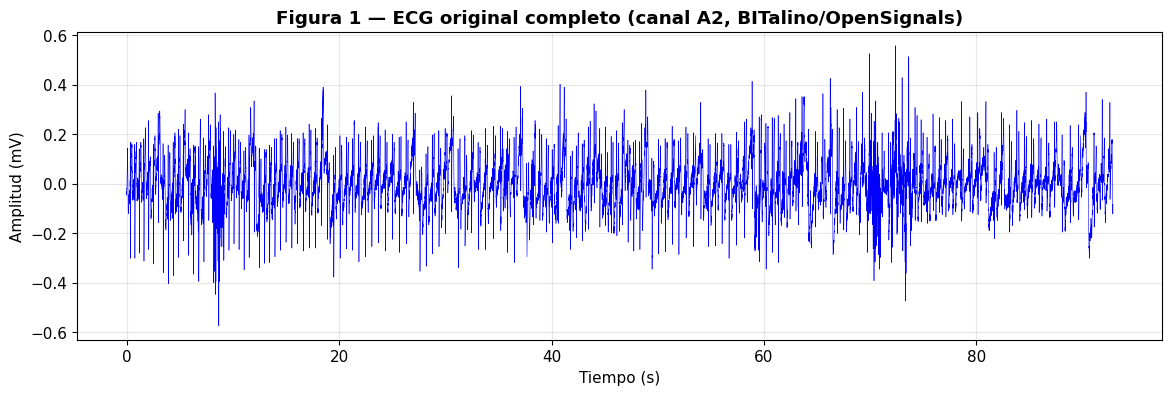

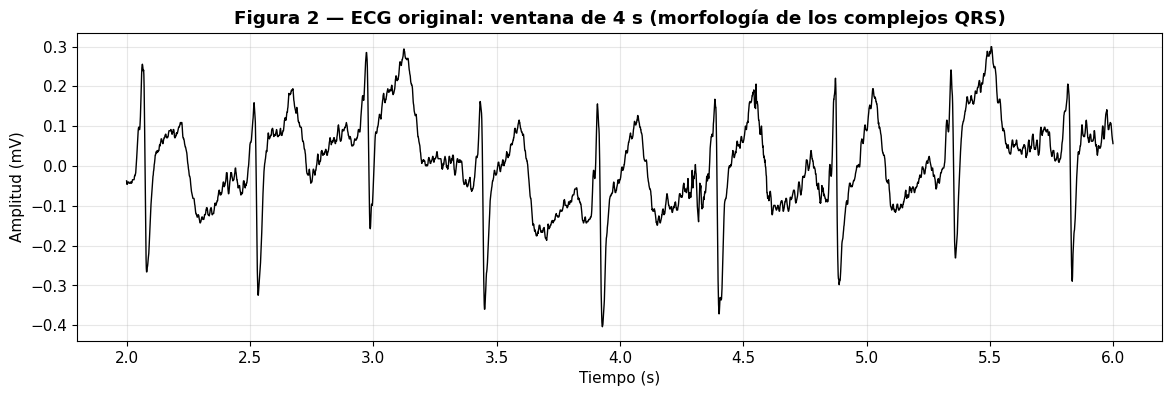

In [36]:
# Ventana de observación para todos los acercamientos (se ajusta si el registro es corto)
DURACION_ZOOM = 4.0                                    # segundos
T_INICIO_ZOOM = 2.0 if duracion_total > 8 else 0.0     # evitamos el inicio del registro
zoom = (t >= T_INICIO_ZOOM) & (t < T_INICIO_ZOOM + DURACION_ZOOM)

# Figura 1: ECG completo
plt.figure(figsize=(14, 4))
plt.plot(t, ecg_original, color="blue", lw=0.4)
plt.title("Figura 1 — ECG original completo (canal A2, BITalino/OpenSignals)")
plt.xlabel("Tiempo (s)"); plt.ylabel("Amplitud (mV)")
plt.show()

# Figura 2: ventana corta
plt.figure(figsize=(14, 4))
plt.plot(t[zoom], ecg_original[zoom], color="black", lw=1)
plt.title(f"Figura 2 — ECG original: ventana de {DURACION_ZOOM:.0f} s (morfología de los complejos QRS)")
plt.xlabel("Tiempo (s)"); plt.ylabel("Amplitud (mV)")
plt.show()

### 🔎 Interpretación
- En la **Figura 1** se observa la señal completa: verifica si la línea de base es estable o presenta deriva (*baseline wander*), y si hay artefactos.
- En la **Figura 2** identifica los **complejos QRS** (picos agudos), las ondas **P** y **T**.
- Recuerda: aunque esta señal es **real**, ya trae consigo cierta cantidad de ruido propio de la adquisición. No es una señal "perfecta".

### ❓ Pregunta al estudiante (Bloque 2)
A partir de la Figura 2, estima la frecuencia cardiaca (latidos por minuto) contando los complejos QRS en la ventana.

✍️ **Respuesta:**
- En la Figura 1 la señal se mantiene aproximadamente centrada alrededor de 0 mV durante el registro, por lo que no se aprecia una deriva severa de la línea base. Sin embargo, existen fluctuaciones, ruido y algunos picos aislados de elevada amplitud que pueden corresponder a artefactos producidos por movimiento, actividad muscular o cambios en el contacto de los electrodos
- En la Figura 2 se distinguen los complejos QRS por sus deflexiones rápidas y pronunciadas. Las ondas T pueden reconocerse como ondas más amplias y suaves posteriores a los QRS, mientras que las ondas P, al poseer menor amplitud y debido al ruido presente, no se distinguen claramente en todos los ciclos.
- En la ventana comprendida aproximadamente entre 2 y 6 s se observan 9 complejos QRS. Por tanto, la frecuencia cardíaca estimada es:
Fc = (9/4)*60 = 135 bpm
 por lo que la frecuencia cardíaca estimada en este segmento es de aproximadamente 135 latidos por minuto.

---
# 🟦 BLOQUE 3 — Contaminación artificial de la señal *(20 min)*

## 3.1 ¿Por qué contaminar artificialmente?

Para **evaluar un filtro necesitamos saber cuál es la "respuesta correcta"**. Si contaminamos nosotros mismos la señal con componentes **conocidas**, podemos comparar la señal filtrada con la original y medir qué tan bien se recuperó.

$$ECG_{contaminado} = ECG_{original} + \text{interferencia}_1 + \text{interferencia}_2 + \text{ruido gaussiano}$$

> ⚠️ **Importante:** esta es una **contaminación artificial y controlada con fines didácticos**. Las frecuencias elegidas **no** representan todas las fuentes reales de ruido de un ECG (en la práctica también hay deriva de línea de base, artefactos de movimiento, ruido muscular/EMG, mal contacto de electrodos, etc.).

**Elección de frecuencias:** en Perú la red eléctrica opera a **60 Hz**, por eso usamos $f_1 = 60$ Hz y su segundo armónico $f_2 = 120$ Hz. Si quieres reproducir el caso europeo, cambia a 50 y 100 Hz. **Todos los parámetros son modificables.**

In [37]:
# =================== PARÁMETROS MODIFICABLES ===================
f1 = 60        # Hz — interferencia 1 (red eléctrica en Perú)
f2 = 120       # Hz — interferencia 2 (armónico de la red)

escala = np.std(ecg_original)   # referencia de amplitud de la propia señal
amplitud_1 = 1.0 * escala       # amplitud de la interferencia 1 (mV)
amplitud_2 = 0.6 * escala       # amplitud de la interferencia 2 (mV)
sigma_ruido = 0.3 * escala      # desviación estándar del ruido gaussiano (mV)
# ===============================================================

# Fases aleatorias (pero reproducibles): las interferencias reales no empiezan en fase cero
fase_1, fase_2 = rng.uniform(0, 2 * np.pi, size=2)

ruido_senoidal_1 = amplitud_1 * np.sin(2 * np.pi * f1 * t + fase_1)
ruido_senoidal_2 = amplitud_2 * np.sin(2 * np.pi * f2 * t + fase_2)
ruido_gaussiano  = rng.normal(0, sigma_ruido, size=len(t))

ecg_contaminado = (
    ecg_original
    + ruido_senoidal_1
    + ruido_senoidal_2
    + ruido_gaussiano
)

print(f"Interferencia 1: {f1} Hz, amplitud {amplitud_1:.3f} mV")
print(f"Interferencia 2: {f2} Hz, amplitud {amplitud_2:.3f} mV")
print(f"Ruido gaussiano: sigma = {sigma_ruido:.3f} mV")

Interferencia 1: 60 Hz, amplitud 0.103 mV
Interferencia 2: 120 Hz, amplitud 0.062 mV
Ruido gaussiano: sigma = 0.031 mV


## 3.2 Visualización de cada componente

Usamos una ventana de **1 segundo** para que las oscilaciones sean distinguibles.

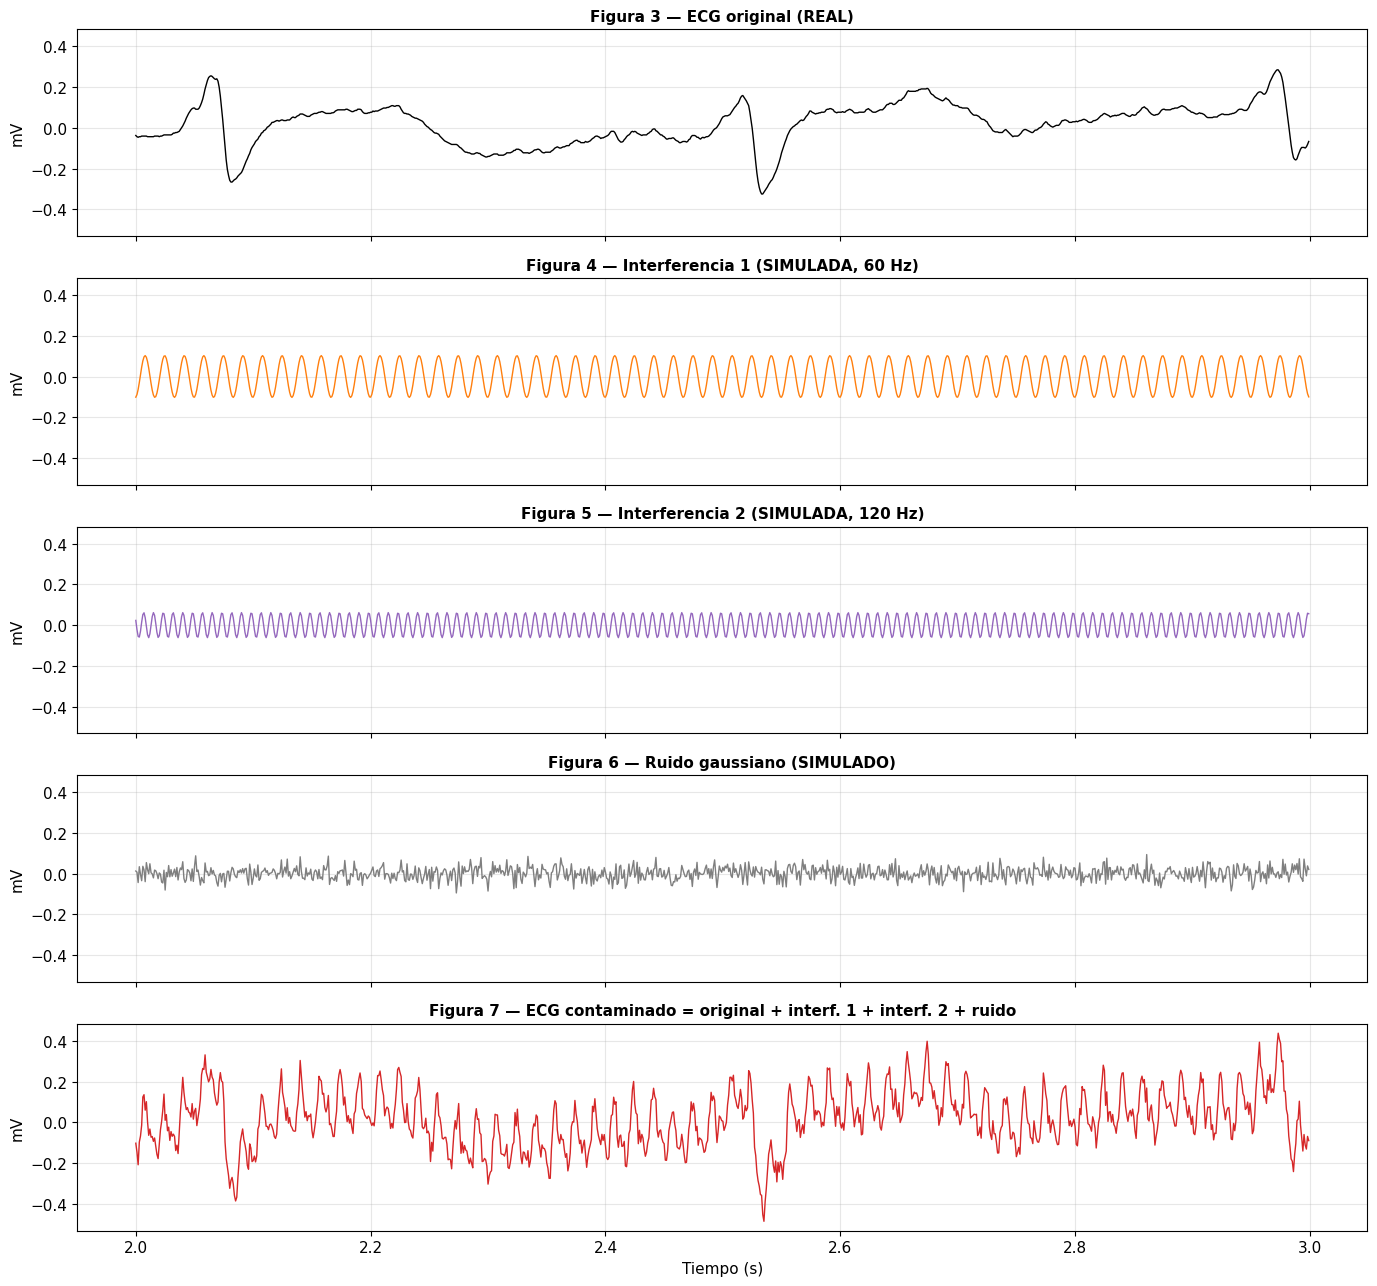

In [38]:
ventana_1s = (t >= T_INICIO_ZOOM) & (t < T_INICIO_ZOOM + 1.0)

componentes = [
    ("Figura 3 — ECG original (REAL)", ecg_original, "black"),
    (f"Figura 4 — Interferencia 1 (SIMULADA, {f1} Hz)", ruido_senoidal_1, "tab:orange"),
    (f"Figura 5 — Interferencia 2 (SIMULADA, {f2} Hz)", ruido_senoidal_2, "tab:purple"),
    ("Figura 6 — Ruido gaussiano (SIMULADO)", ruido_gaussiano, "tab:gray"),
    ("Figura 7 — ECG contaminado = original + interf. 1 + interf. 2 + ruido", ecg_contaminado, "tab:red"),
]

fig, ejes = plt.subplots(len(componentes), 1, figsize=(14, 13), sharex=True, sharey=True)
for eje, (titulo, senal, color) in zip(ejes, componentes):
    eje.plot(t[ventana_1s], senal[ventana_1s], color=color, lw=1)
    eje.set_title(titulo, fontsize=11)
    eje.set_ylabel("mV")
ejes[-1].set_xlabel("Tiempo (s)")
plt.tight_layout(); plt.show()

```text
ECG original
        ↓
+ interferencias (f1, f2)
        ↓
+ ruido gaussiano
        ↓
ECG contaminado
```

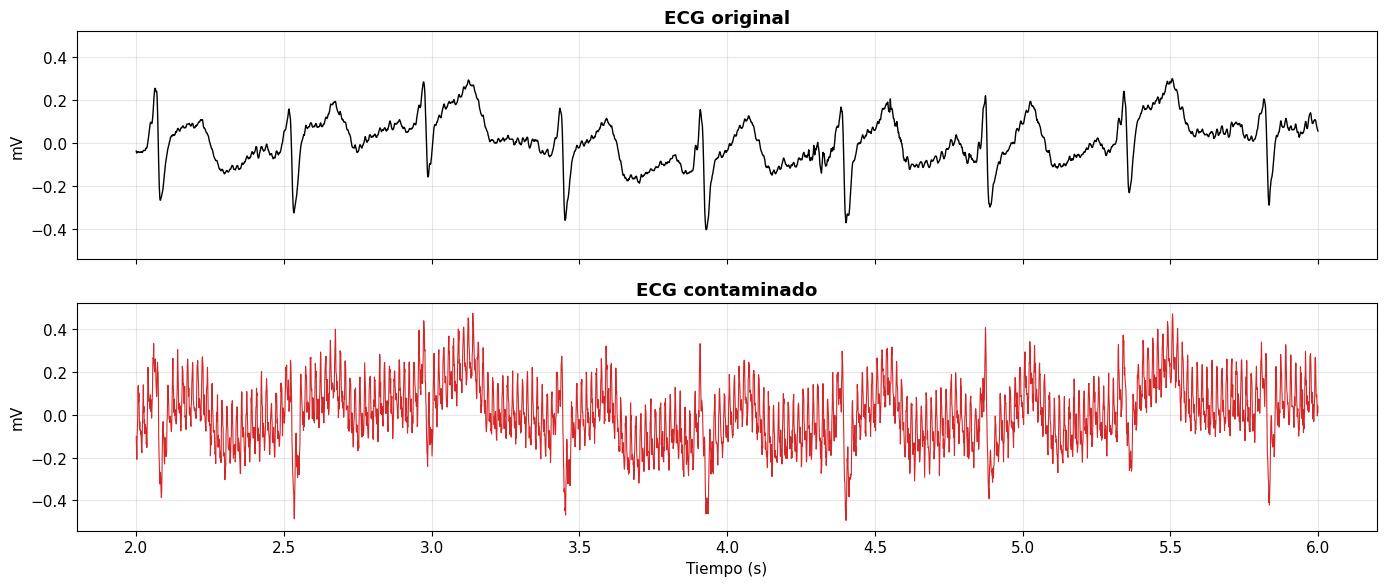

In [39]:
# Comparación directa en la ventana de 4 s
fig, ejes = plt.subplots(2, 1, figsize=(14, 6), sharex=True, sharey=True)
ejes[0].plot(t[zoom], ecg_original[zoom], color="black", lw=1)
ejes[0].set_title("ECG original")
ejes[1].plot(t[zoom], ecg_contaminado[zoom], color="tab:red", lw=0.8)
ejes[1].set_title("ECG contaminado")
for eje in ejes: eje.set_ylabel("mV")
ejes[1].set_xlabel("Tiempo (s)")
plt.tight_layout(); plt.show()

### 🔎 Observa y anota
- ¿Cambió la amplitud aparente de la señal?
- ¿Se conserva la forma de las ondas P y T?
- ¿Qué oscilaciones regulares aparecen?
- ¿Hay ruido de alta frecuencia ("grosor" del trazo)?
- ¿Es más difícil identificar los complejos QRS?

✍️ **Respuesta:**
- La amplitud si aumento puesto que en el ECG original, la mayor parte de la señal se encuentra aproximadamente entre -0.4mV y 0.3mv. Mientras que despues de contarmilarla aparecen valores entre -0.5mV y +0.5mV. Sin embargo, este aumento de amplitud no fue por la actividad cardiaca sino porque la señal registrada seria de ECG + ruido. En conclusion, la amplitud aumento debido a la suma de las componentes de interferencia de 60 Hz y 120 Hz del ruido gaussiano. Lo que no significa que la actividad eléctrica cardíaca haya aumentaod, sino que el ruido se superpone al ECG y modifica los alores medidos.
- En el ECG original, aunque existia ruido todavía se podia distinguir las ondas P yT. Despues de añadir la contaminación, las ondas pequeñas quedan mucho más difíciles de reconocer.Esto afecta especialmente a la onda P, porque normalmente presenta una amplitud menor que el QRS. Por lo que las ondas P y T se vuelven considerablemente menos visibles después de la contaminación. La onda P es especialmente difícil de identificar debido a su menor amplitud, mientras que la onda T todavía puede reconocerse parcialmente como una onda más amplia posterior al QRS, aunque su morfología está alterada por el ruido.
- Aparecen oscilaciones rápidas y aproximadamente periódicas superpuestas al ECG, producidas principalmente por las componentes sinusoidales de 60 Hz y 120 Hz. A estas se suma el comportamiento aleatorio generado por el ruido gaussiano.
- Sí, ya que el trazo del ECG contaminado es mas grueso, irregular y con oscilaciones rápidas debido a las componentes de alta frecuencia de 60 y 120 Hz y al ruido gaussiano. Estas componentes generan rápidas variaciones de amplitud alrededor de la señal cardíaca original.
- Visualmente todavía podemos encontrar muchos QRS porque conocemos la forma original y vemos deflexiones grandes. Sin embargo, un algoritmo automático podría confundir ruido con QRS, generando falsos positivos o incluso dejando de detectar algunos QRS reales.

## 3.3 Análisis en el dominio de la frecuencia

> Una señal puede analizarse no solamente en función del tiempo, sino también en función de sus **componentes frecuenciales**.

```text
Dominio temporal
        ↕   Transformada de Fourier (FFT)
Dominio frecuencial
```

Intuitivamente, la FFT responde: *¿cuánto de cada frecuencia contiene la señal?* Una senoide pura de frecuencia $f_0$ aparece como **un pico estrecho** en $f_0$. El ruido gaussiano, en cambio, reparte su energía en **todas** las frecuencias (fondo plano).

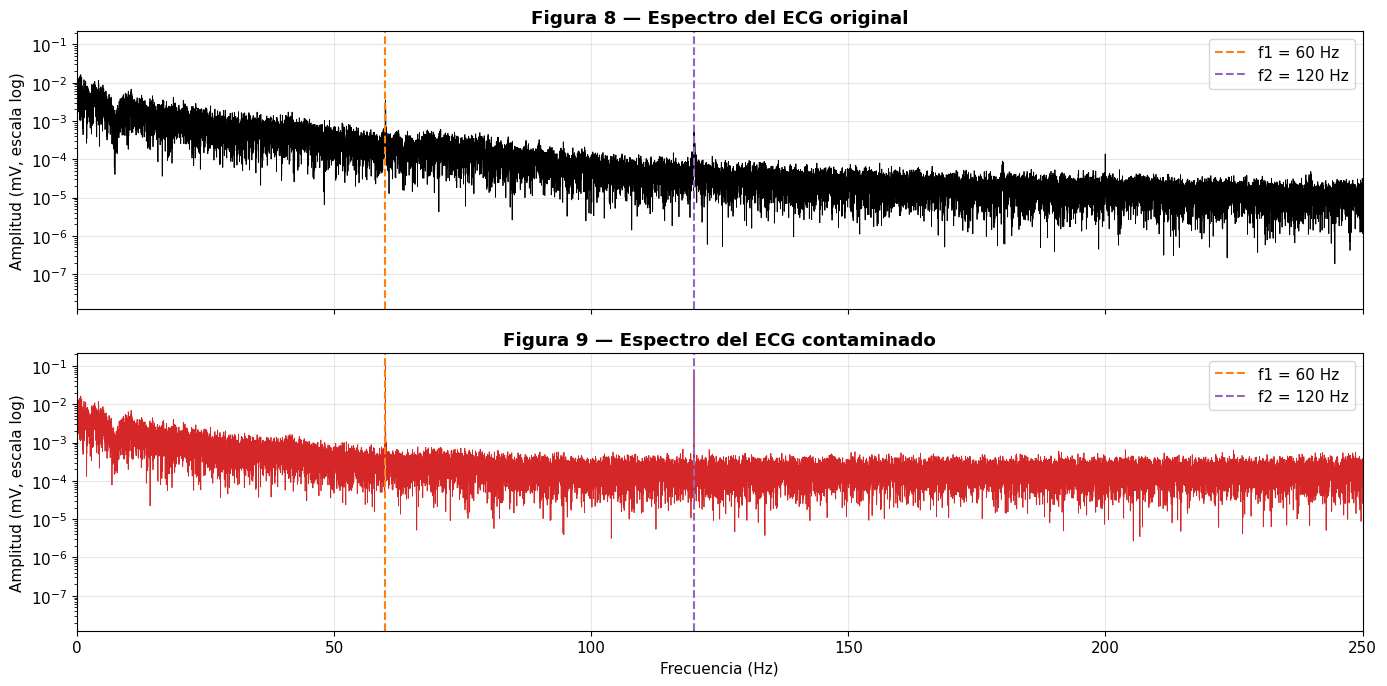

In [40]:
def espectro_amplitud(x, Fs):
    """Espectro de amplitud de un solo lado usando la FFT de NumPy."""
    N = len(x)
    X = np.fft.rfft(x - np.mean(x))
    frecuencias = np.fft.rfftfreq(N, d=1/Fs)
    amplitud = 2 * np.abs(X) / N
    return frecuencias[1:], amplitud[1:]   # omitimos 0 Hz (la media ya fue restada)

freq, amp_original = espectro_amplitud(ecg_original, Fs)
_,    amp_contaminado = espectro_amplitud(ecg_contaminado, Fs)

F_MAX_GRAFICO = min(250, Fs / 2)
fig, ejes = plt.subplots(2, 1, figsize=(14, 7), sharex=True, sharey=True)
ejes[0].semilogy(freq, amp_original, color="black", lw=0.6)
ejes[0].set_title("Figura 8 — Espectro del ECG original")
ejes[1].semilogy(freq, amp_contaminado, color="tab:red", lw=0.6)
ejes[1].set_title("Figura 9 — Espectro del ECG contaminado")
for eje in ejes:
    eje.axvline(f1, color="tab:orange", ls="--", label=f"f1 = {f1} Hz")
    eje.axvline(f2, color="tab:purple", ls="--", label=f"f2 = {f2} Hz")
    eje.set_ylabel("Amplitud (mV, escala log)")
    eje.legend(loc="upper right")
ejes[1].set_xlabel("Frecuencia (Hz)")
ejes[1].set_xlim(0, F_MAX_GRAFICO)
plt.tight_layout(); plt.show()

### 🔎 Interpretación
- El ECG concentra la mayor parte de su energía en **bajas frecuencias** (aprox. < 40 Hz).
- En el espectro contaminado aparecen **dos picos nítidos** exactamente en $f_1$ y $f_2$: son las interferencias que **nosotros** introdujimos.
- El ruido gaussiano **eleva el "piso"** del espectro en todas las frecuencias.
- Si en el ECG original ya aparece algún pico en 60 Hz, ¡esa sería interferencia **real** de la adquisición!

### ❓ Pregunta al estudiante
¿Por qué la interferencia aparece como un pico y el ruido gaussiano como un fondo? ¿Cuál de los dos será más fácil de eliminar con un filtro?

✍️ **Respuesta:**
- La interferencia sinusoidal aparece como un **pico estrecho** porque una senoide ideal concentra prácticamente toda su energía en una frecuencia específica. En este caso, las componentes agregadas de **60 Hz y 120 Hz** producen picos bien definidos en esas frecuencias dentro de la FFT.
- El ruido gaussiano, en cambio, contiene componentes distribuidas en un rango amplio de frecuencias. Por eso no produce un único pico, sino que **eleva el piso del espectro**, generando un fondo de energía repartido en muchas frecuencias.
- La interferencia sinusoidal es más fácil de eliminar de manera selectiva porque conocemos exactamente dónde se encuentra y podemos utilizar, por ejemplo, un **filtro notch** centrado en 60 Hz y 120 Hz. El ruido gaussiano es más difícil de retirar completamente porque parte de su contenido se superpone con las mismas frecuencias donde existe información real del ECG; eliminarlo de forma demasiado agresiva también podría eliminar información fisiológica.


---
# 🟦 BLOQUE 4 — Aplicación de filtros digitales *(25 min)*

## 4.1 Tipos de filtros

| Filtro | Deja pasar | Uso típico en ECG |
|---|---|---|
| **Pasa-bajas** | Frecuencias por debajo de $f_c$ | Atenuar ruido de alta frecuencia (EMG, ruido electrónico). |
| **Pasa-altas** | Frecuencias por encima de $f_c$ | Eliminar la deriva de línea de base (respiración, movimiento). |
| **Pasa-banda** | Frecuencias entre $f_{c1}$ y $f_{c2}$ | Combinar ambos: típico 0.5 – 40 Hz para monitoreo. |
| **Notch (rechaza-banda)** | Todo excepto una banda muy estrecha | Eliminar una interferencia de frecuencia conocida (red eléctrica). |

**Herramientas de `scipy.signal`:**
- `butter`: diseña un filtro Butterworth (respuesta plana en la banda de paso).
- `iirnotch`: diseña un filtro notch centrado en una frecuencia.
- `filtfilt`: aplica el filtro hacia adelante y hacia atrás → **fase cero** (no desplaza los QRS en el tiempo).
- `freqz`: calcula la respuesta en frecuencia del filtro.

> 💡 Para el pasa-banda usamos la forma **SOS** (*second-order sections*) con `sosfiltfilt`, que es el equivalente numéricamente estable de `filtfilt` cuando la frecuencia de corte es muy baja respecto a $F_s$ (0.5 Hz frente a 1000 Hz).

In [41]:
def respuesta_sos(sos, Fs, n_puntos=16384):
    """Respuesta en frecuencia de un filtro en formato SOS (compatible con varias versiones de SciPy)."""
    funcion = getattr(signal, "freqz_sos", None) or signal.sosfreqz
    return funcion(sos, worN=n_puntos, fs=Fs)

def graficar_respuesta(w, h, titulo, marcas=()):
    plt.figure(figsize=(14, 3.5))
    plt.plot(w, 20 * np.log10(np.maximum(np.abs(h), 1e-10)), color="tab:blue")
    for f in marcas:
        plt.axvline(f, color="tab:red", ls="--", lw=1)
    plt.ylim(-80, 5); plt.xlim(0, F_MAX_GRAFICO)
    plt.title(titulo); plt.xlabel("Frecuencia (Hz)"); plt.ylabel("Ganancia (dB)")
    plt.show()

## 4.2 Experimento A — Filtro pasa-banda (Butterworth 0.5 – 40 Hz)

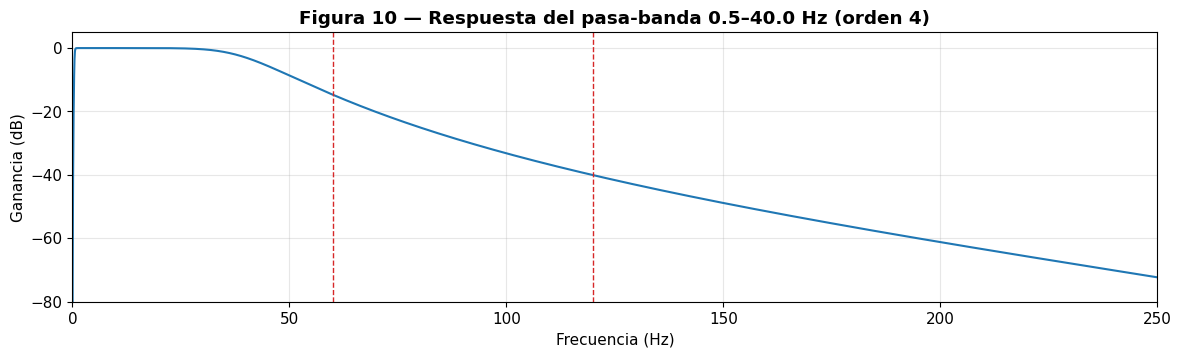

In [42]:
# =================== PARÁMETROS MODIFICABLES ===================
fc_baja = 0.5     # Hz
fc_alta = 40.0    # Hz
orden_pb = 4
# ===============================================================

sos_pasabanda = signal.butter(orden_pb, [fc_baja, fc_alta], btype="bandpass", fs=Fs, output="sos")
ecg_pasabanda = signal.sosfiltfilt(sos_pasabanda, ecg_contaminado)

w, h = respuesta_sos(sos_pasabanda, Fs)
graficar_respuesta(w, h, f"Figura 10 — Respuesta del pasa-banda {fc_baja}–{fc_alta} Hz (orden {orden_pb})", marcas=(f1, f2))

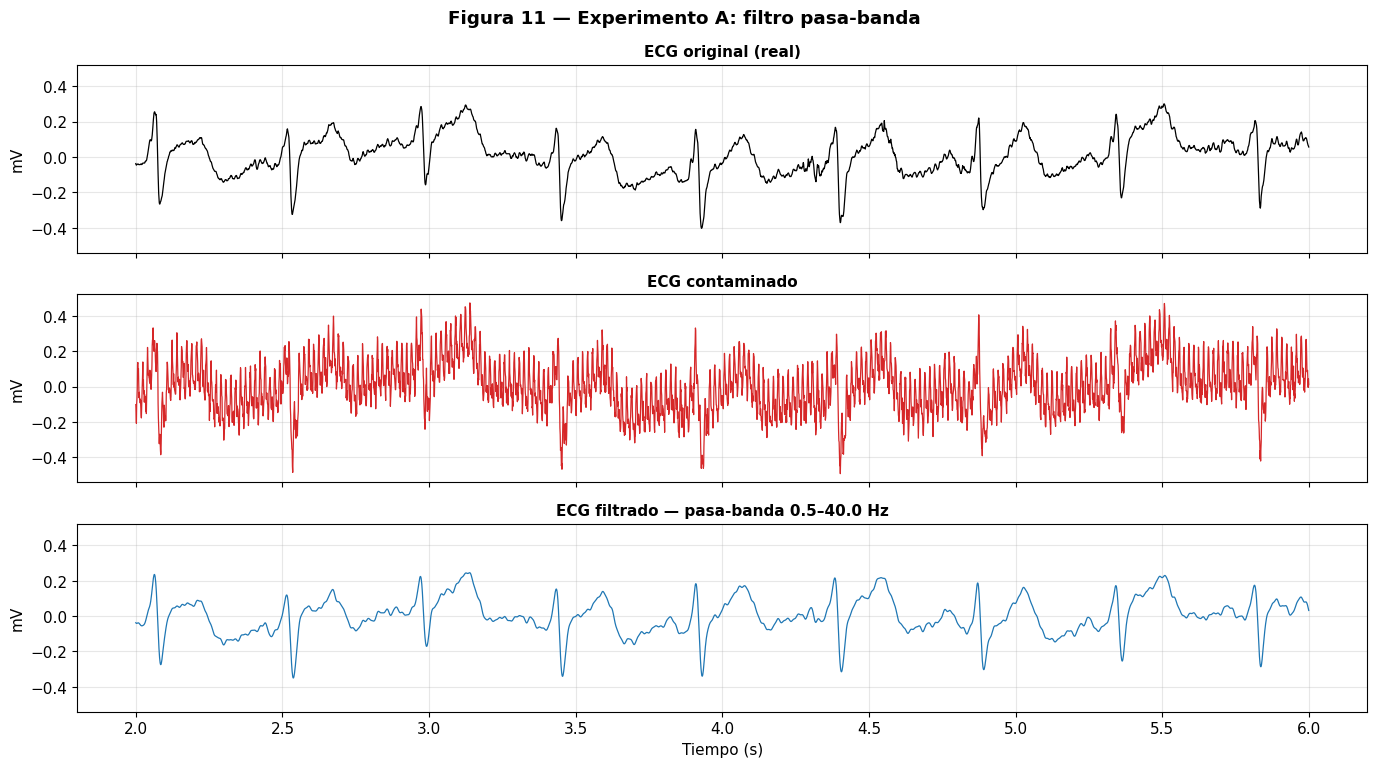

In [43]:
def comparar_senales(lista, titulo_general, mascara=zoom):
    """Grafica varias señales (titulo, señal, color) apiladas en la misma ventana temporal."""
    fig, ejes = plt.subplots(len(lista), 1, figsize=(14, 2.6 * len(lista)), sharex=True, sharey=True)
    for eje, (titulo, senal, color) in zip(ejes, lista):
        eje.plot(t[mascara], senal[mascara], color=color, lw=0.9)
        eje.set_title(titulo, fontsize=11); eje.set_ylabel("mV")
    ejes[-1].set_xlabel("Tiempo (s)")
    fig.suptitle(titulo_general, fontweight="bold")
    plt.tight_layout(); plt.show()

comparar_senales([
    ("ECG original (real)", ecg_original, "black"),
    ("ECG contaminado", ecg_contaminado, "tab:red"),
    (f"ECG filtrado — pasa-banda {fc_baja}–{fc_alta} Hz", ecg_pasabanda, "tab:blue"),
], "Figura 11 — Experimento A: filtro pasa-banda")

### 🔎 Interpretación — Experimento A
- **¿Qué se eliminó?** Ambas interferencias ($f_1$ y $f_2$ están fuera de la banda de paso) y la mayor parte del ruido gaussiano de alta frecuencia.
- **¿Qué permanece?** El ruido gaussiano que cae **dentro** de 0.5 – 40 Hz: ningún filtro lineal puede separarlo del ECG porque comparten frecuencias.
- **¿Qué se pudo afectar?** El pasa-banda también elimina contenido **real** del ECG: la deriva de línea de base (< 0.5 Hz) y parte del contenido de alta frecuencia del QRS (> 40 Hz). Observa si los picos R se ven un poco más bajos o redondeados.

## 4.3 Experimento B — Filtro notch

El notch elimina **una frecuencia concreta** y deja prácticamente intacto el resto del espectro. El **factor de calidad** $Q$ controla el ancho de la muesca: $\text{ancho} \approx f_0 / Q$.

**B1:** notch solo en $f_1$. **B2:** dos notch en cascada ($f_1$ y $f_2$).

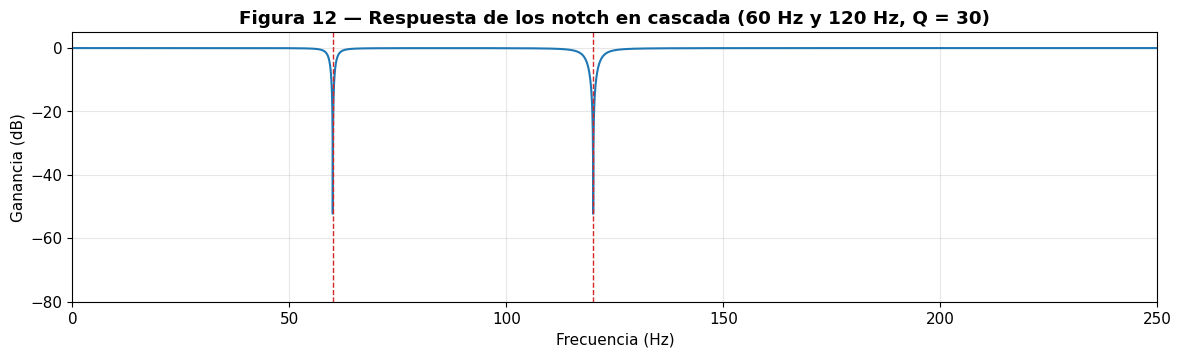

In [56]:
Q = 30   # factor de calidad (mayor Q → muesca más estrecha)

b_notch1, a_notch1 = signal.iirnotch(f1, Q, fs=Fs)
b_notch2, a_notch2 = signal.iirnotch(f2, Q, fs=Fs)

# B1: solo f1
ecg_notch_f1 = signal.filtfilt(b_notch1, a_notch1, ecg_contaminado)
# B2: f1 y luego f2 (cascada)
ecg_notch_f1f2 = signal.filtfilt(b_notch2, a_notch2, ecg_notch_f1)

# Respuesta en frecuencia de la cascada (producto de ambas respuestas)
w, h1 = signal.freqz(b_notch1, a_notch1, worN=16384, fs=Fs)
_, h2 = signal.freqz(b_notch2, a_notch2, worN=16384, fs=Fs)
graficar_respuesta(w, h1 * h2, f"Figura 12 — Respuesta de los notch en cascada ({f1} Hz y {f2} Hz, Q = {Q})", marcas=(f1, f2))

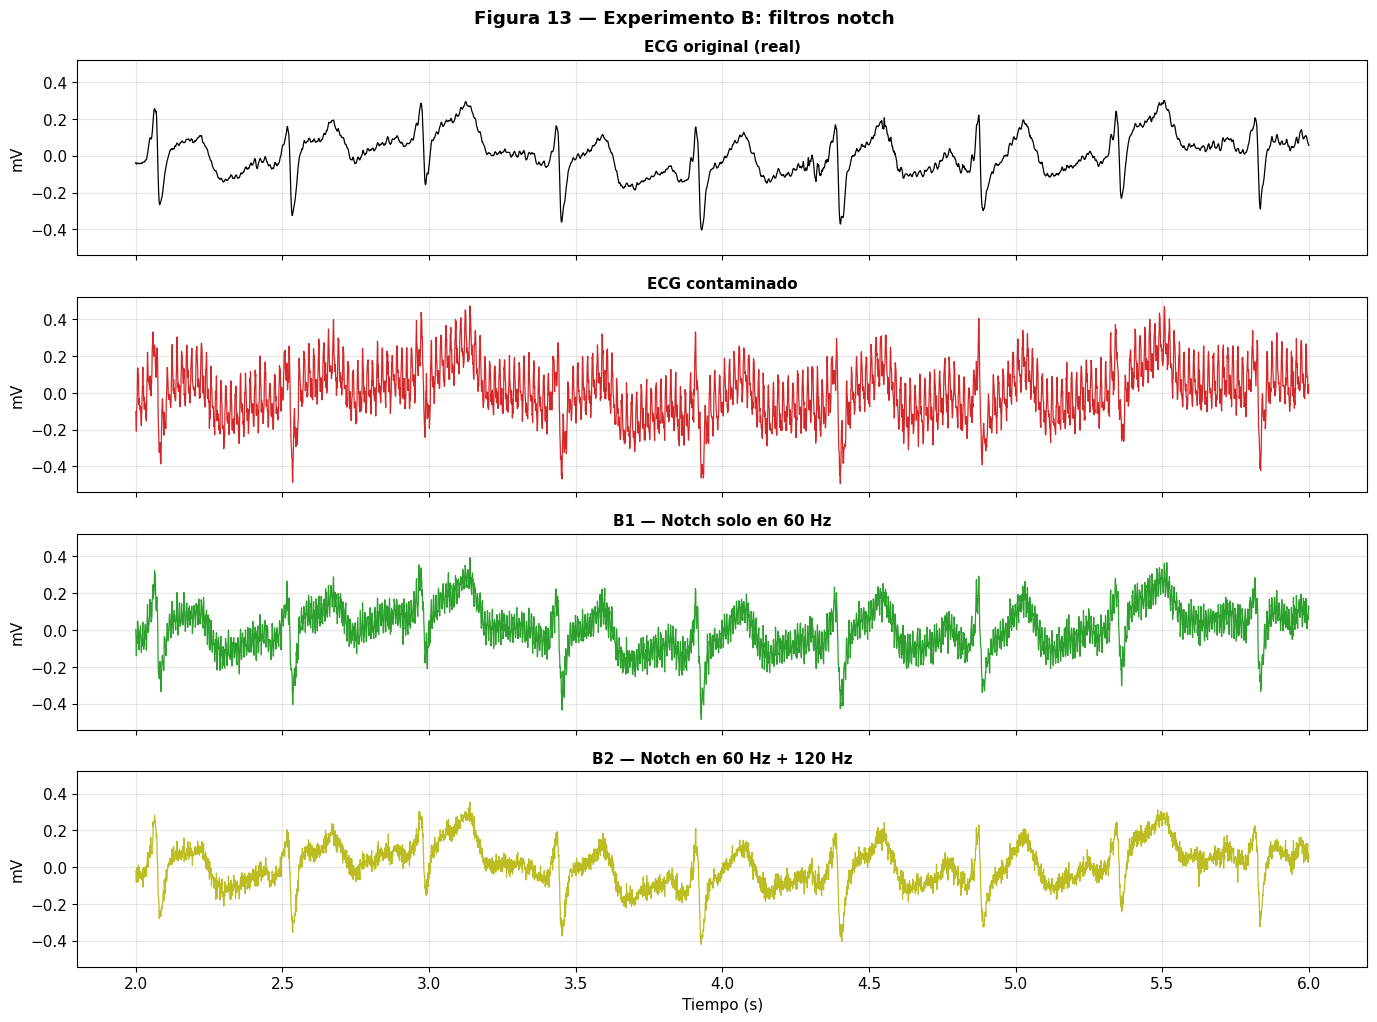

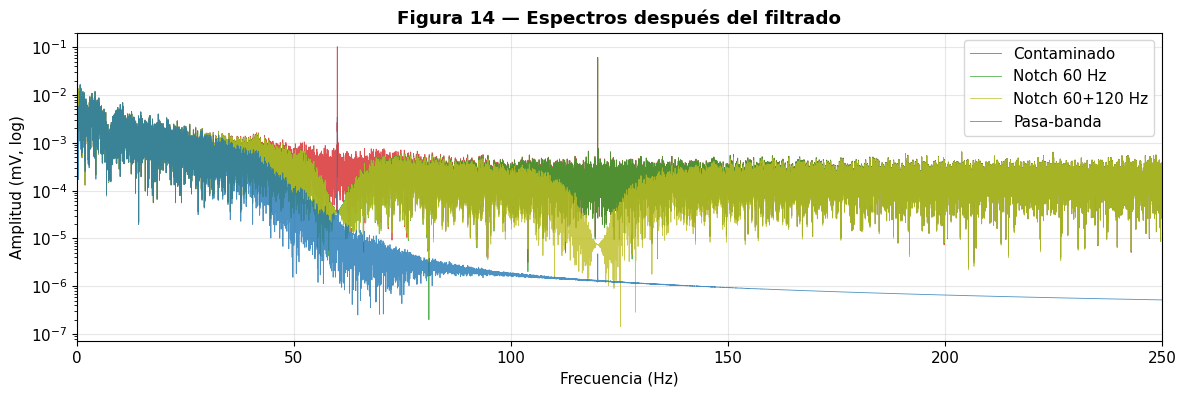

In [45]:
comparar_senales([
    ("ECG original (real)", ecg_original, "black"),
    ("ECG contaminado", ecg_contaminado, "tab:red"),
    (f"B1 — Notch solo en {f1} Hz", ecg_notch_f1, "tab:green"),
    (f"B2 — Notch en {f1} Hz + {f2} Hz", ecg_notch_f1f2, "tab:olive"),
], "Figura 13 — Experimento B: filtros notch")

# Espectros después de cada filtrado
fig, eje = plt.subplots(figsize=(14, 4))
for etiqueta, senal, color in [("Contaminado", ecg_contaminado, "tab:red"),
                               (f"Notch {f1} Hz", ecg_notch_f1, "tab:green"),
                               (f"Notch {f1}+{f2} Hz", ecg_notch_f1f2, "tab:olive"),
                               ("Pasa-banda", ecg_pasabanda, "tab:blue")]:
    fr, am = espectro_amplitud(senal, Fs)
    eje.semilogy(fr, am, lw=0.6, label=etiqueta, color=color, alpha=0.8)
eje.set_xlim(0, F_MAX_GRAFICO); eje.legend()
eje.set_title("Figura 14 — Espectros después del filtrado")
eje.set_xlabel("Frecuencia (Hz)"); eje.set_ylabel("Amplitud (mV, log)")
plt.show()

### 🔎 Interpretación — Experimento B
- **B1** elimina el pico en $f_1$, pero el de $f_2$ **sigue ahí**: el notch solo actúa donde se lo indicamos.
- **B2** elimina ambos picos, pero el **ruido gaussiano permanece** (el notch no reduce el ruido de banda ancha).
- **Ventaja:** el notch altera muy poco la morfología del ECG porque solo "corta" una banda estrecha.
- **Limitación:** exige conocer la frecuencia exacta y que esta **no cambie** en el tiempo.

### ❓ Pregunta al estudiante
Cambia `Q` a 5 y luego a 100. ¿Qué ocurre con el ancho de la muesca (Figura 12) y con la señal filtrada?

✍️ **Respuesta:**
- El factor de calidad $Q$ controla qué tan **estrecha o ancha** es la banda que elimina el filtro notch. De manera aproximada, el ancho de banda puede relacionarse mediante $BW \approx f_0/Q$.
- Con **Q = 5**, la muesca se vuelve mucho más ancha. Para 60 Hz, por ejemplo, el ancho aproximado sería $60/5 = 12$ Hz. Esto facilita eliminar una interferencia que varíe ligeramente de frecuencia, pero también elimina más componentes cercanas que podrían pertenecer al ECG. Por ello, la señal puede presentar **mayor distorsión morfológica**.
- Con **Q = 100**, la muesca es mucho más estrecha; alrededor de 60 Hz su ancho aproximado sería $60/100 = 0.6$ Hz. Esto conserva mejor las frecuencias vecinas y, por tanto, la morfología del ECG, pero exige que la interferencia esté localizada con bastante precisión. Si la frecuencia de la interferencia cambia, una muesca demasiado estrecha podría no eliminarla completamente.
- Por ello, un valor intermedio como **Q = 30** representa un compromiso entre cancelar la interferencia y evitar eliminar innecesariamente información fisiológica.


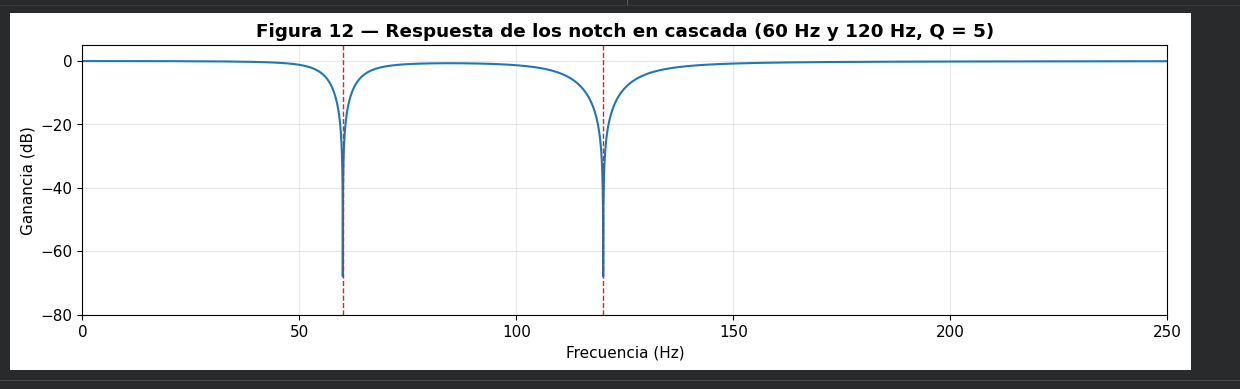

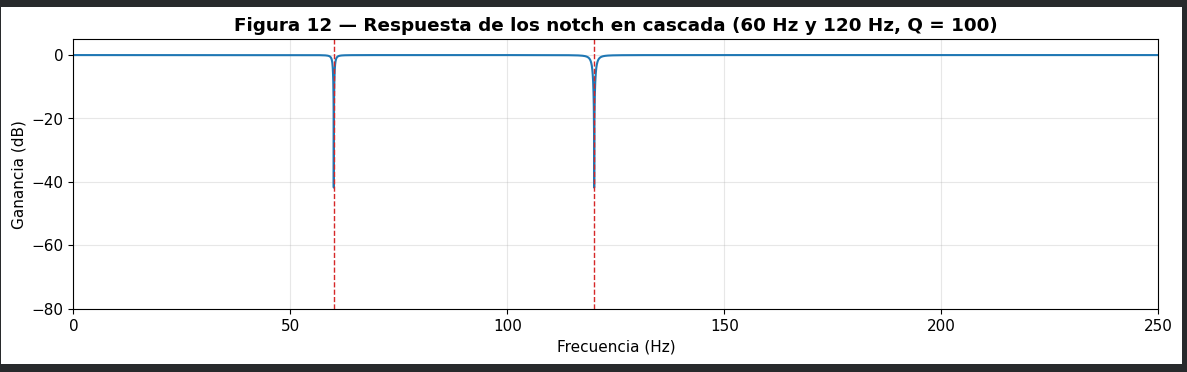

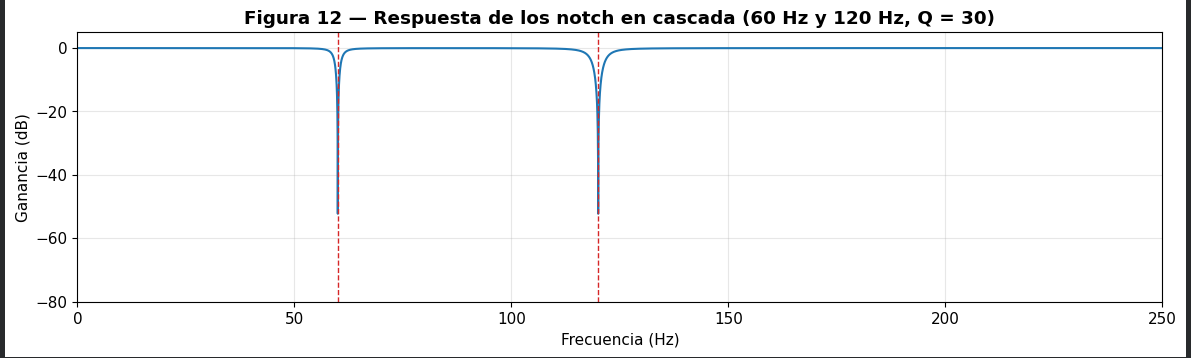

## 4.4 Comparación cuantitativa

Las métricas **complementan** (no reemplazan) la evaluación visual:

| Métrica | Fórmula | Interpretación |
|---|---|---|
| **RMSE** | $\sqrt{\frac{1}{N}\sum (x - \hat{x})^2}$ | Error promedio (mV). **Menor es mejor.** |
| **SNR** | $10\log_{10}\frac{\sum x^2}{\sum (x-\hat{x})^2}$ | Relación señal/error en dB. **Mayor es mejor.** |
| **Correlación** $r$ | coeficiente de Pearson | Similitud de forma (1 = idéntica). |

donde $x$ es el ECG original y $\hat{x}$ la señal evaluada. Excluimos los primeros y últimos 2 s para evitar efectos de borde (y el tiempo de convergencia del filtro adaptativo que veremos luego).

In [46]:
MARGEN_S = 2.0
evaluacion = (t >= MARGEN_S) & (t <= t[-1] - MARGEN_S)

def calcular_metricas(referencia, estimada, mascara=evaluacion):
    x, y = referencia[mascara], estimada[mascara]
    error = y - x
    rmse = np.sqrt(np.mean(error ** 2))
    snr = 10 * np.log10(np.sum(x ** 2) / np.sum(error ** 2))
    r = np.corrcoef(x, y)[0, 1]
    return {"RMSE (mV)": rmse, "SNR (dB)": snr, "Correlación r": r}

resultados = {
    "Contaminado (sin filtrar)": calcular_metricas(ecg_original, ecg_contaminado),
    "A — Pasa-banda": calcular_metricas(ecg_original, ecg_pasabanda),
    f"B1 — Notch {f1} Hz": calcular_metricas(ecg_original, ecg_notch_f1),
    f"B2 — Notch {f1}+{f2} Hz": calcular_metricas(ecg_original, ecg_notch_f1f2),
}
pd.DataFrame(resultados).T.round(4)

,RMSE (mV),SNR (dB),Correlación r
Contaminado (sin filtrar),0.0898,1.1916,0.7544
A — Pasa-banda,0.0362,9.0788,0.9365
B1 — Notch 60 Hz,0.0528,5.8044,0.8882
B2 — Notch 60+120 Hz,0.0297,10.8172,0.9602


### ¿Cuánto modifica el filtro a la propia señal original?

Un detalle importante: el pasa-banda **también** cambia el ECG original (quita su deriva de base y su contenido > 40 Hz). Para separar "ruido no eliminado" de "distorsión del filtro", filtramos el **original limpio** y lo comparamos consigo mismo.

In [47]:
ecg_original_pasabanda = signal.sosfiltfilt(sos_pasabanda, ecg_original)
ecg_original_notch = signal.filtfilt(b_notch2, a_notch2, signal.filtfilt(b_notch1, a_notch1, ecg_original))

pd.DataFrame({
    "Pasa-banda aplicado al ORIGINAL": calcular_metricas(ecg_original, ecg_original_pasabanda),
    "Notch f1+f2 aplicado al ORIGINAL": calcular_metricas(ecg_original, ecg_original_notch),
}).T.round(4)

,RMSE (mV),SNR (dB),Correlación r
Pasa-banda aplicado al ORIGINAL,0.0352,9.3210,0.9403
Notch f1+f2 aplicado al ORIGINAL,0.0085,21.6637,0.9966


### 🔎 Interpretación
- Si el pasa-banda aplicado al original **ya** produce un error apreciable, parte del "error" del Experimento A **no es ruido residual**, sino **distorsión introducida por el filtro** (pérdida de deriva de base y de componentes rápidas del QRS).
- El notch casi no modifica el original → distorsión mínima, pero tampoco reduce el ruido gaussiano.
- Conclusión: **ninguna métrica aislada cuenta toda la historia**.

### ❓ Pregunta al estudiante
¿Qué filtro obtuvo mejor SNR? ¿Coincide con lo que observaste visualmente? Explica cualquier diferencia.

✍️ **Respuesta:**
- Entre los filtros convencionales evaluados, el mejor resultado de SNR fue obtenido por **B2 — Notch de 60 Hz + 120 Hz**, con aproximadamente **10.39 dB**. El pasa-banda obtuvo **9.08 dB**, el notch únicamente en 60 Hz obtuvo **5.69 dB**, mientras que la señal contaminada sin filtrar tenía solo **1.19 dB**.
- Este resultado coincide en gran parte con la observación visual: al aplicar los dos notch desaparecen las oscilaciones periódicas dominantes de 60 y 120 Hz y la morfología del ECG se conserva bastante bien. Sin embargo, todavía se observa ruido gaussiano porque el notch actúa únicamente en bandas muy estrechas.
- El pasa-banda puede verse visualmente más suave porque elimina gran cantidad de contenido fuera de 0.5–40 Hz, pero su SNR es ligeramente menor. Esto ocurre porque también elimina parte de la señal ECG real, especialmente componentes rápidas asociadas al QRS. De hecho, al aplicar el pasa-banda al ECG original se obtiene una correlación de aproximadamente **0.94**, mientras que el notch aplicado al original conserva una correlación cercana a **0.998**, lo que demuestra que una señal aparentemente más “limpia” no necesariamente está menos distorsionada.


---
# 🟦 BLOQUE 5 — Filtros adaptativos y Transformada Wavelet *(20 min)*

## 5.1 ¿Qué es un filtro adaptativo?

Un filtro **convencional** tiene coeficientes **fijos**: se diseña una vez y se aplica igual a toda la señal. Un filtro **adaptativo** **modifica sus coeficientes muestra a muestra** en función de la información que recibe, por lo que puede seguir interferencias cuya amplitud o fase cambian en el tiempo.

```text
Señal contaminada d[n] ──────────────────────────►(+)──► e[n] = ECG estimado
                                                    ▲(−)
                                                    │
señal de referencia x[n] ──► Filtro adaptativo ──► y[n] = interferencia estimada
                                  ▲
                                  └──── se ajusta usando el error e[n]
```

| Concepto | Significado en este laboratorio |
|---|---|
| **Señal de referencia** $x[n]$ | Señal **correlacionada con la interferencia** pero no con el ECG (aquí: senos y cosenos de $f_1$ y $f_2$). En la práctica puede provenir de un sensor que capta la red eléctrica. |
| **Coeficientes** $w$ | Pesos que el filtro ajusta para "imitar" la interferencia. |
| **Salida** $y[n] = w^T x[n]$ | Estimación de la interferencia. |
| **Error** $e[n] = d[n] - y[n]$ | Lo que queda al restar la interferencia estimada: **es nuestro ECG limpio**. |
| **Adaptación (LMS)** | $w[n+1] = w[n] + 2\mu\, e[n]\, x[n]$ |
| **Paso** $\mu$ | Velocidad de aprendizaje: grande → rápido pero inestable/distorsionante; pequeño → lento pero preciso. |

El algoritmo **LMS** (*Least Mean Squares*) minimiza poco a poco la potencia del error. Como el ECG no está correlacionado con la referencia, la única forma de reducir el error es **cancelar la interferencia**.

In [59]:
def filtro_lms(senal_contaminada, referencias, mu):
    """
    Cancelador adaptativo de interferencias con algoritmo LMS (versión didáctica).
    senal_contaminada : vector d[n] de tamaño N
    referencias       : matriz N x M (cada columna es una señal de referencia)
    mu                : paso de adaptación
    Devuelve: e (señal limpia estimada), y (interferencia estimada), historial de pesos
    """
    N, M = referencias.shape
    w = np.zeros(M)                       # los coeficientes empiezan en cero: el filtro "no sabe nada"
    y = np.zeros(N)
    e = np.zeros(N)
    historial_w = np.zeros((N, M))
    for n in range(N):
        x_n = referencias[n]              # vector de referencia en el instante n
        y[n] = w @ x_n                    # 1) estimar la interferencia
        e[n] = senal_contaminada[n] - y[n]  # 2) calcular el error (ECG estimado)
        w = w + 2 * mu * e[n] * x_n       # 3) actualizar los coeficientes (LMS)
        historial_w[n] = w
    return e, y, historial_w

# Referencias: seno y coseno de cada frecuencia (permiten ajustar amplitud Y fase)
referencias = np.column_stack([
    np.sin(2 * np.pi * f1 * t), np.cos(2 * np.pi * f1 * t),
    np.sin(2 * np.pi * f2 * t), np.cos(2 * np.pi * f2 * t),
])

MU = 0.05  # =================== PARÁMETRO MODIFICABLE ===================
ecg_lms, interferencia_estimada, pesos = filtro_lms(ecg_contaminado, referencias, MU)
print("Filtrado adaptativo completado.")

Filtrado adaptativo completado.


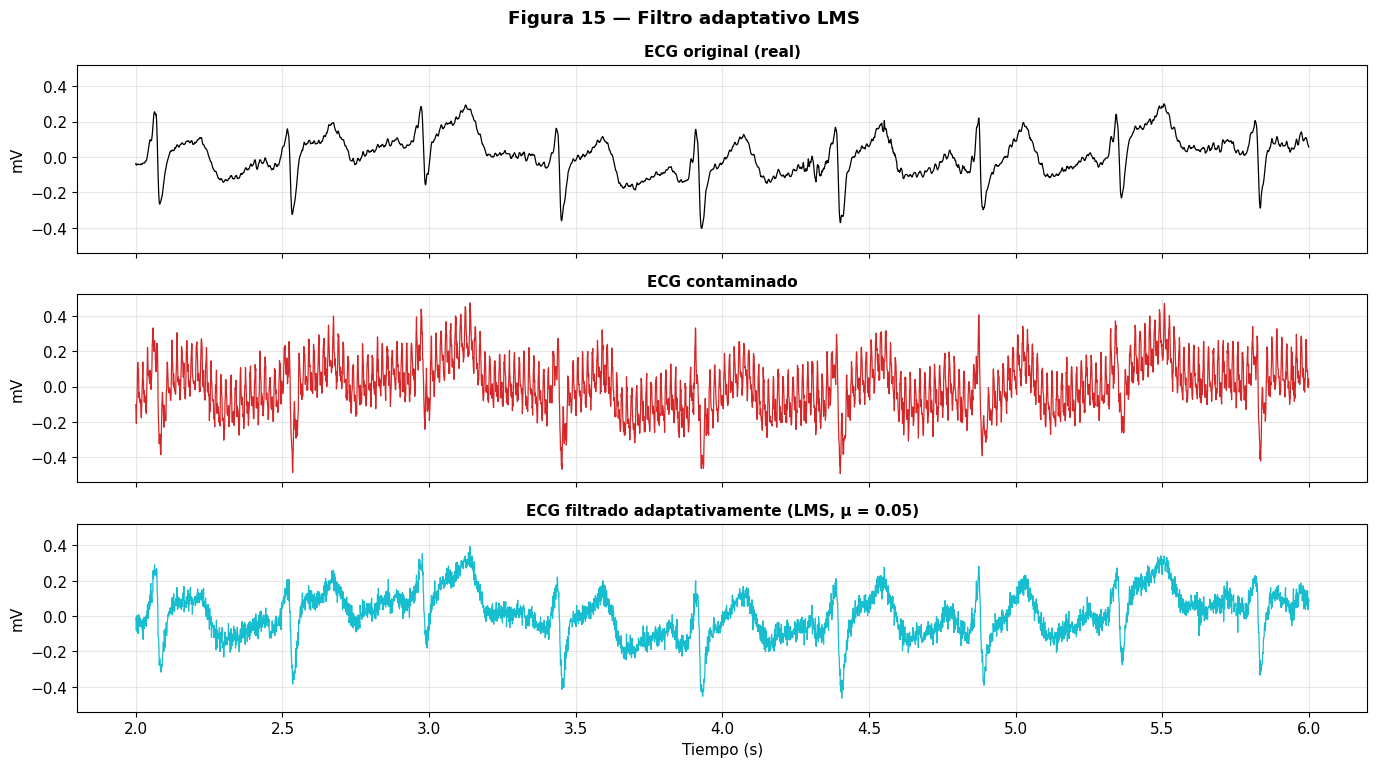

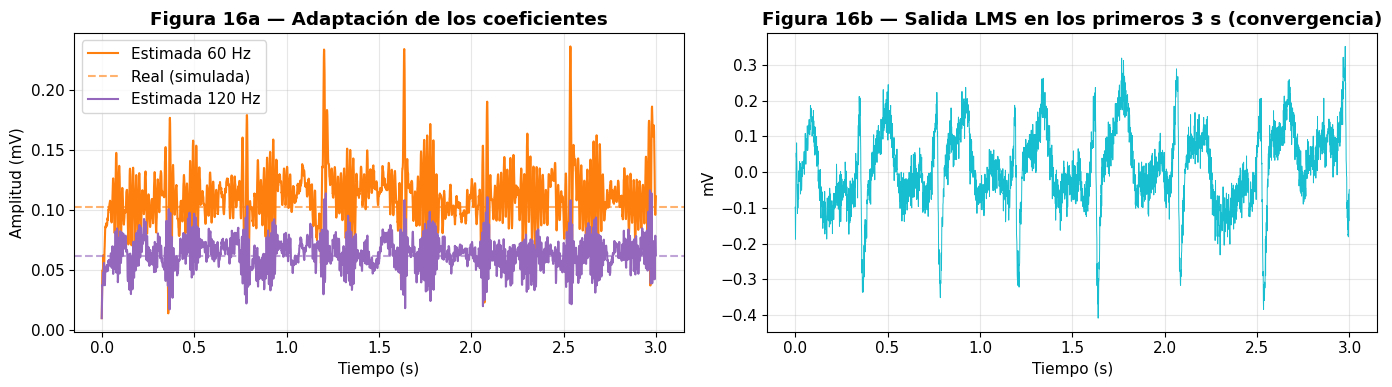

,RMSE (mV),SNR (dB),Correlación r
Contaminado (sin filtrar),0.0898,1.1916,0.7544
A — Pasa-banda,0.0362,9.0788,0.9365
B1 — Notch 60 Hz,0.0528,5.8044,0.8882
B2 — Notch 60+120 Hz,0.0297,10.8172,0.9602
LMS adaptativo,0.0370,8.8966,0.9532
Wavelet (denoising),0.0434,7.5159,0.9072
Híbrido notch + Wavelet,0.0298,10.7722,0.9635


In [60]:
comparar_senales([
    ("ECG original (real)", ecg_original, "black"),
    ("ECG contaminado", ecg_contaminado, "tab:red"),
    (f"ECG filtrado adaptativamente (LMS, μ = {MU})", ecg_lms, "tab:cyan"),
], "Figura 15 — Filtro adaptativo LMS")

# ¿Cómo "aprende" el filtro? Amplitud estimada de cada interferencia en el tiempo
amplitud_est_1 = np.hypot(pesos[:, 0], pesos[:, 1])
amplitud_est_2 = np.hypot(pesos[:, 2], pesos[:, 3])
primeros = t < 3.0

fig, ejes = plt.subplots(1, 2, figsize=(14, 4))
ejes[0].plot(t[primeros], amplitud_est_1[primeros], label=f"Estimada {f1} Hz", color="tab:orange")
ejes[0].axhline(amplitud_1, ls="--", color="tab:orange", alpha=0.6, label="Real (simulada)")
ejes[0].plot(t[primeros], amplitud_est_2[primeros], label=f"Estimada {f2} Hz", color="tab:purple")
ejes[0].axhline(amplitud_2, ls="--", color="tab:purple", alpha=0.6)
ejes[0].set_title("Figura 16a — Adaptación de los coeficientes")
ejes[0].set_xlabel("Tiempo (s)"); ejes[0].set_ylabel("Amplitud (mV)"); ejes[0].legend()

ejes[1].plot(t[primeros], ecg_lms[primeros], color="tab:cyan", lw=0.7)
ejes[1].set_title("Figura 16b — Salida LMS en los primeros 3 s (convergencia)")
ejes[1].set_xlabel("Tiempo (s)"); ejes[1].set_ylabel("mV")
plt.tight_layout(); plt.show()

resultados["LMS adaptativo"] = calcular_metricas(ecg_original, ecg_lms)
pd.DataFrame(resultados).T.round(4)

### 🔎 Interpretación — Filtro adaptativo
- Al inicio los coeficientes valen cero: la salida **todavía contiene la interferencia**. En unos cientos de milisegundos los coeficientes **convergen** a la amplitud real de cada interferencia (Figura 16a).
- Una vez adaptado, el LMS cancela $f_1$ y $f_2$ con muy poca alteración del ECG.
- **El ruido gaussiano permanece**: no está correlacionado con la referencia, así que el filtro no puede "aprenderlo".
- Su gran ventaja frente al notch aparece cuando la interferencia **cambia** (amplitud/fase variables): el LMS la sigue; el notch fijo no se entera.

### ❓ Pregunta al estudiante
Cambia `MU` a 0.0005 y a 0.05. ¿Qué pasa con la velocidad de convergencia (Figura 16a) y con la calidad de la señal?

✍️ **Respuesta:**
- El parámetro $\mu$ determina el tamaño de cada actualización de los coeficientes del algoritmo LMS. Por ello existe un compromiso entre **velocidad de aprendizaje** y **estabilidad/calidad de la estimación**.
- Con **$\mu = 0.0005$**, las actualizaciones son muy pequeñas. Los coeficientes necesitan más muestras para aproximarse a las amplitudes reales de 60 y 120 Hz, por lo que en la Figura 16a la convergencia debe observarse **más lenta**. Durante ese intervalo inicial permanece una mayor cantidad de interferencia en la salida, aunque una vez que converge el ajuste suele ser más estable.
- Con **$\mu = 0.05$**, los coeficientes cambian mucho más rápido y la convergencia ocurre en menos muestras. Sin embargo, un paso grande hace que los pesos fluctúen más alrededor de la solución óptima y puede introducir mayor error residual o pequeñas distorsiones; si $\mu$ aumentara demasiado, el LMS incluso podría volverse inestable.
- Por tanto, el valor utilizado inicialmente, **$\mu = 0.005$**, funciona como un compromiso: aprende suficientemente rápido sin hacer que la adaptación sea excesivamente sensible al ruido o a variaciones momentáneas de la señal.


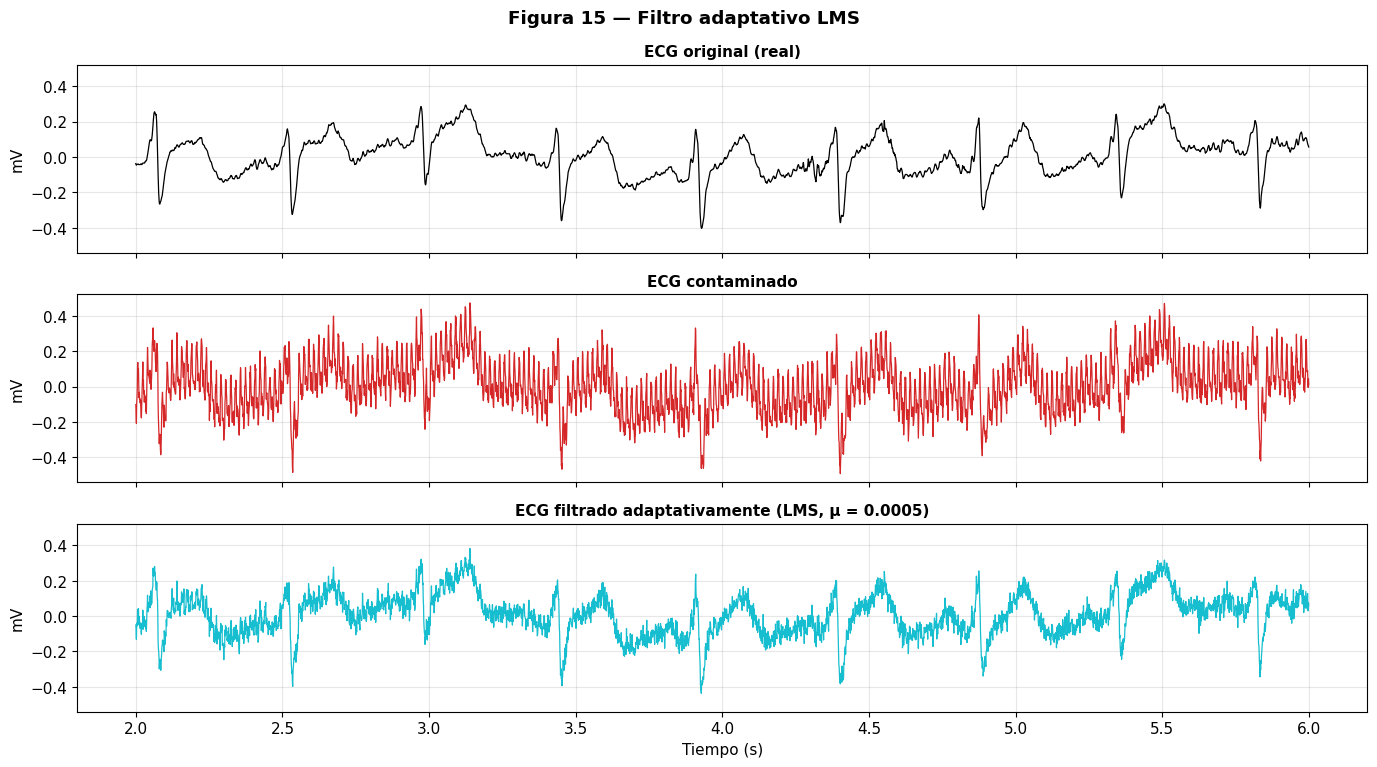

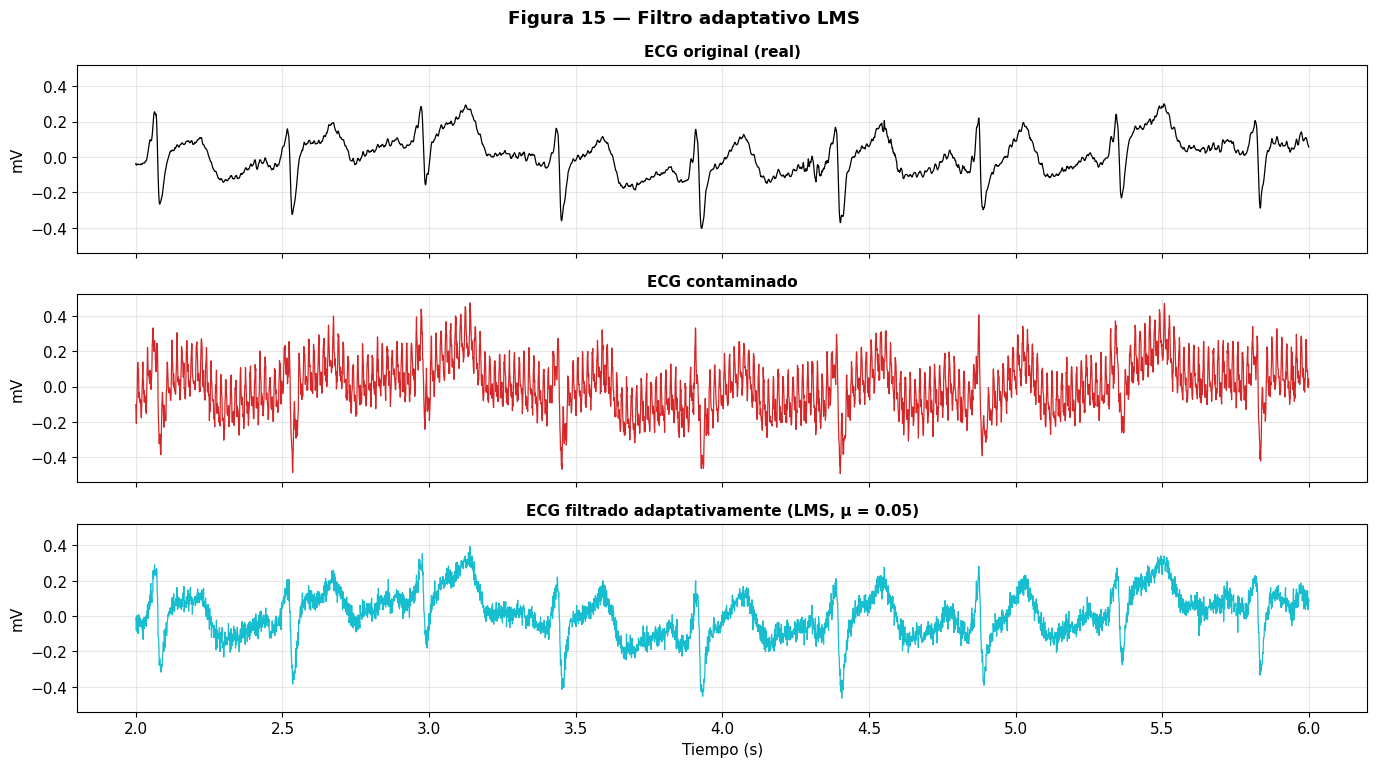

## 5.2 Transformada Wavelet

> ### ¿Para qué sirve la Transformada Wavelet en el procesamiento de señales biomédicas?

La FFT nos dice **qué frecuencias** hay en la señal, pero **no cuándo** aparecen (analiza la señal completa de forma global). La **Transformada Wavelet** descompone la señal usando pequeñas "ondas" (*wavelets*) de duración limitada, a distintas **escalas**:

- **Escalas pequeñas** → detalles rápidos (alta frecuencia), bien localizados en el tiempo.
- **Escalas grandes** → tendencias lentas (baja frecuencia).

Esto encaja muy bien con el ECG:
- el **complejo QRS** es un evento rápido y localizado;
- las ondas **P** y **T** son más lentas;
- el **ruido** suele dispersarse en los detalles finos con coeficientes pequeños;
- la **deriva de base** vive en la aproximación más gruesa.

### Descomposición Wavelet Discreta (DWT)

En cada nivel la señal se divide en una **aproximación** (A, parte lenta) y un **detalle** (D, parte rápida); la aproximación se vuelve a dividir:

```text
Señal ─┬─► D1 (Fs/4 – Fs/2)
       └─► A1 ─┬─► D2 (Fs/8 – Fs/4)
               └─► A2 ─┬─► D3 ...
                       └─► ... ─► A_L (la parte más lenta)
```

Usaremos la wavelet **Daubechies 4 (`db4`)**, muy empleada en ECG porque su forma se parece a la de un complejo QRS.

In [50]:
WAVELET = "db4"
nivel_max = pywt.dwt_max_level(len(ecg_original), pywt.Wavelet(WAVELET).dec_len)
NIVEL = min(8, nivel_max)

# Banda de frecuencias aproximada de cada nivel
print(f"Wavelet: {WAVELET} | Niveles: {NIVEL}\n")
print(f"A{NIVEL}: 0 – {Fs / 2**(NIVEL+1):.1f} Hz (aproximación)")
for j in range(NIVEL, 0, -1):
    print(f"D{j}: {Fs / 2**(j+1):.1f} – {Fs / 2**j:.1f} Hz")
print(f"\nInterferencia 1 ({f1} Hz) y 2 ({f2} Hz): ubícalas en la tabla anterior.")

def componentes_por_nivel(x, wavelet, nivel):
    """Reconstruye por separado la contribución de la aproximación y de cada detalle (en el dominio del tiempo)."""
    coefs = pywt.wavedec(x, wavelet, level=nivel)
    componentes = {}
    nombres = [f"A{nivel}"] + [f"D{j}" for j in range(nivel, 0, -1)]
    for i, nombre in enumerate(nombres):
        coefs_solo = [c if k == i else np.zeros_like(c) for k, c in enumerate(coefs)]
        componentes[nombre] = pywt.waverec(coefs_solo, wavelet)[:len(x)]
    return componentes

comp_original = componentes_por_nivel(ecg_original, WAVELET, NIVEL)
comp_contaminado = componentes_por_nivel(ecg_contaminado, WAVELET, NIVEL)

Wavelet: db4 | Niveles: 8

A8: 0 – 2.0 Hz (aproximación)
D8: 2.0 – 3.9 Hz
D7: 3.9 – 7.8 Hz
D6: 7.8 – 15.6 Hz
D5: 15.6 – 31.2 Hz
D4: 31.2 – 62.5 Hz
D3: 62.5 – 125.0 Hz
D2: 125.0 – 250.0 Hz
D1: 250.0 – 500.0 Hz

Interferencia 1 (60 Hz) y 2 (120 Hz): ubícalas en la tabla anterior.


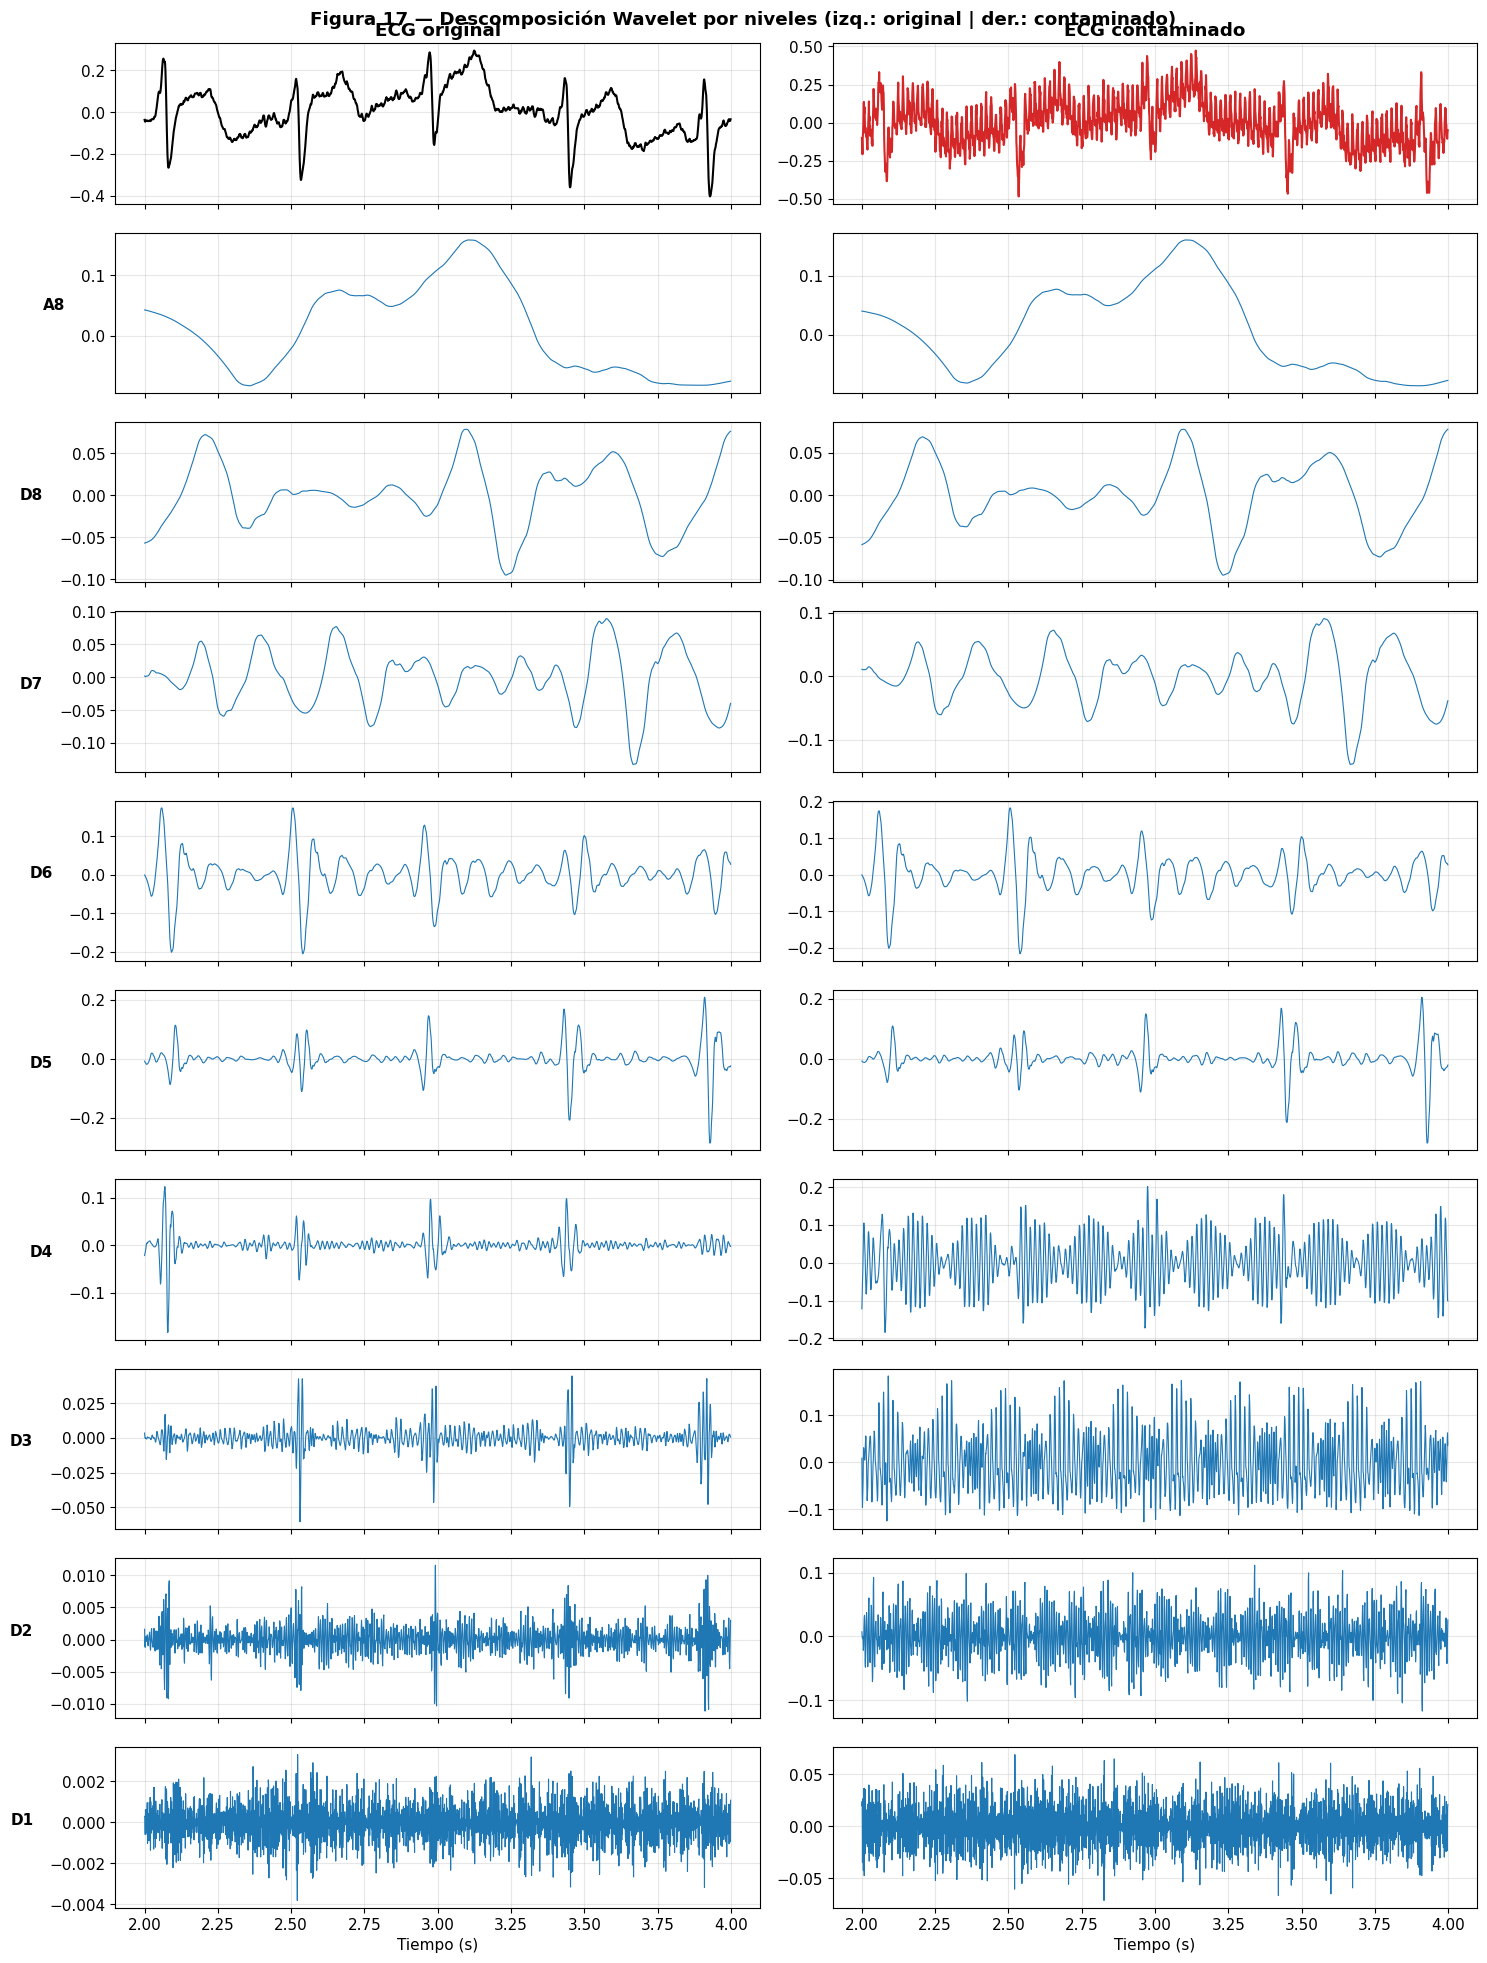

In [51]:
ventana_2s = (t >= T_INICIO_ZOOM) & (t < T_INICIO_ZOOM + 2.0)
nombres = list(comp_original.keys())

fig, ejes = plt.subplots(len(nombres) + 1, 2, figsize=(15, 2 * (len(nombres) + 1)), sharex=True)
ejes[0, 0].plot(t[ventana_2s], ecg_original[ventana_2s], color="black"); ejes[0, 0].set_title("ECG original")
ejes[0, 1].plot(t[ventana_2s], ecg_contaminado[ventana_2s], color="tab:red"); ejes[0, 1].set_title("ECG contaminado")
for i, nombre in enumerate(nombres, start=1):
    ejes[i, 0].plot(t[ventana_2s], comp_original[nombre][ventana_2s], color="tab:blue", lw=0.8)
    ejes[i, 1].plot(t[ventana_2s], comp_contaminado[nombre][ventana_2s], color="tab:blue", lw=0.8)
    ejes[i, 0].set_ylabel(nombre, rotation=0, labelpad=20, fontweight="bold")
ejes[-1, 0].set_xlabel("Tiempo (s)"); ejes[-1, 1].set_xlabel("Tiempo (s)")
fig.suptitle("Figura 17 — Descomposición Wavelet por niveles (izq.: original | der.: contaminado)", fontweight="bold")
plt.tight_layout(); plt.show()

### 🔎 Interpretación — Descomposición
- **D1, D2** (frecuencias altas): en el original casi no hay energía; en el contaminado aparecen dominados por **ruido gaussiano**.
- **D3, D4**: aquí "caen" las interferencias de 120 Hz y 60 Hz (oscilaciones regulares).
- **D5 – D7**: contienen la energía de los **complejos QRS** (picos localizados en el tiempo).
- **A8 (aproximación)**: tendencia lenta y **deriva de línea de base**.
- Observa que en los detalles el QRS aparece **localizado en el tiempo**: eso es lo que la FFT global no puede mostrar.

## 5.3 *Denoising* mediante Wavelet (umbralización)

Idea: los eventos importantes (QRS) producen **pocos coeficientes grandes**; el ruido produce **muchos coeficientes pequeños**. Entonces:

1. Descomponer la señal (DWT).
2. Estimar el nivel de ruido con el detalle más fino: $\sigma = \text{mediana}(|D_1|)/0.6745$.
3. Calcular un umbral (universal): $\lambda = \sigma\sqrt{2\ln N}$.
4. **Umbralizar** los detalles: los coeficientes con $|c| < \lambda$ se anulan, los demás se reducen (*soft thresholding*).
5. Reconstruir la señal (IDWT).

Umbral universal aplicado: 0.1486


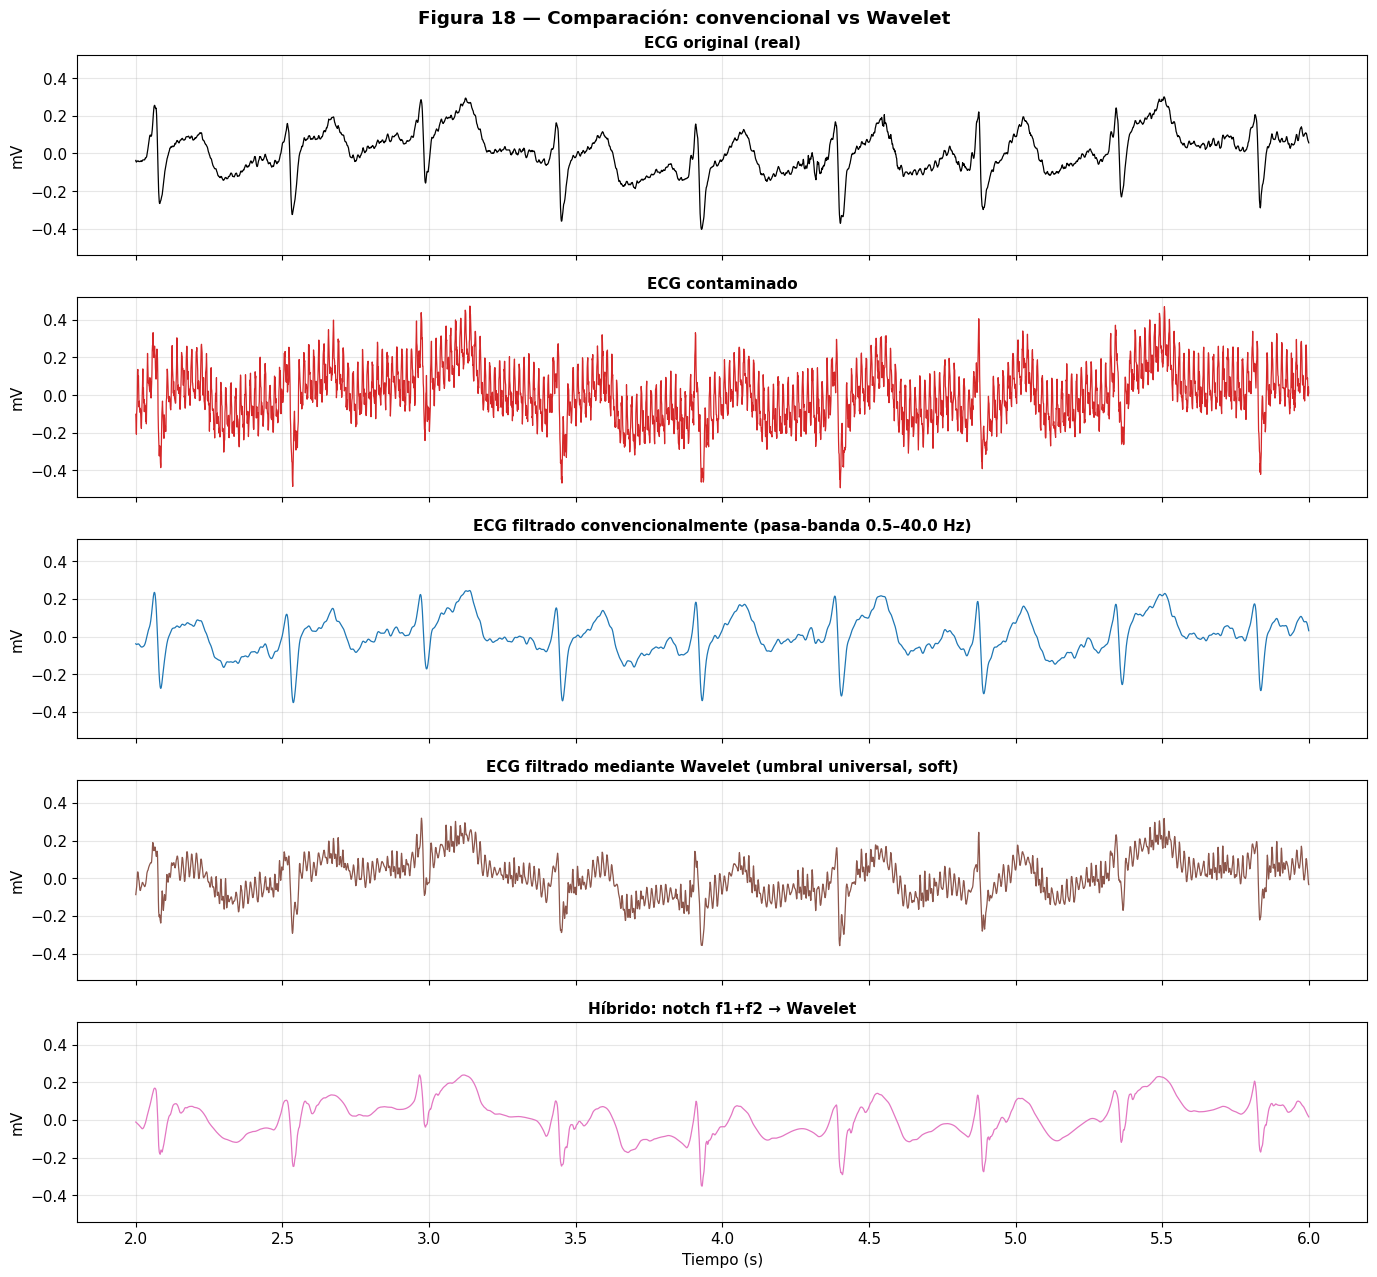

,RMSE (mV),SNR (dB),Correlación r
Contaminado (sin filtrar),0.0898,1.1916,0.7544
A — Pasa-banda,0.0362,9.0788,0.9365
B1 — Notch 60 Hz,0.0528,5.8044,0.8882
B2 — Notch 60+120 Hz,0.0297,10.8172,0.9602
LMS adaptativo,0.0318,10.2159,0.9561
Wavelet (denoising),0.0434,7.5159,0.9072
Híbrido notch + Wavelet,0.0298,10.7722,0.9635


In [52]:
def denoising_wavelet(x, wavelet=WAVELET, nivel=NIVEL, modo="soft"):
    coefs = pywt.wavedec(x, wavelet, level=nivel)
    sigma = np.median(np.abs(coefs[-1])) / 0.6745            # ruido estimado a partir de D1
    umbral = sigma * np.sqrt(2 * np.log(len(x)))              # umbral universal
    coefs_umbral = [coefs[0]] + [pywt.threshold(c, umbral, mode=modo) for c in coefs[1:]]
    x_limpia = pywt.waverec(coefs_umbral, wavelet)[:len(x)]
    return x_limpia, umbral

# 1) Wavelet aplicada directamente a la señal contaminada
ecg_wavelet, umbral = denoising_wavelet(ecg_contaminado)
# 2) Enfoque híbrido: primero notch (quita interferencias), luego wavelet (quita ruido gaussiano)
ecg_hibrido, _ = denoising_wavelet(ecg_notch_f1f2)

print(f"Umbral universal aplicado: {umbral:.4f}")

comparar_senales([
    ("ECG original (real)", ecg_original, "black"),
    ("ECG contaminado", ecg_contaminado, "tab:red"),
    (f"ECG filtrado convencionalmente (pasa-banda {fc_baja}–{fc_alta} Hz)", ecg_pasabanda, "tab:blue"),
    ("ECG filtrado mediante Wavelet (umbral universal, soft)", ecg_wavelet, "tab:brown"),
    ("Híbrido: notch f1+f2 → Wavelet", ecg_hibrido, "tab:pink"),
], "Figura 18 — Comparación: convencional vs Wavelet")

resultados["Wavelet (denoising)"] = calcular_metricas(ecg_original, ecg_wavelet)
resultados["Híbrido notch + Wavelet"] = calcular_metricas(ecg_original, ecg_hibrido)
pd.DataFrame(resultados).T.round(4)

### 🔎 Interpretación — *Denoising* Wavelet
- La umbralización **reduce eficazmente el ruido gaussiano** (banda ancha, coeficientes pequeños) y tiende a **conservar los QRS**, porque sus coeficientes son grandes.
- Sin embargo, las **interferencias sinusoidales intensas** generan coeficientes grandes en D3–D4 que **superan el umbral** → pueden sobrevivir al *denoising*. La Wavelet no es la herramienta ideal para una interferencia de banda estrecha.
- El enfoque **híbrido** combina fortalezas: el notch quita las interferencias y la Wavelet el ruido de banda ancha.
- **Posibles distorsiones:** el *soft thresholding* reduce ligeramente la amplitud de los picos y puede generar pequeñas oscilaciones cerca de los QRS.

### ❓ Pregunta al estudiante
Cambia `modo="soft"` por `modo="hard"` y prueba la wavelet `"sym8"` en lugar de `"db4"`. ¿Cómo cambian la forma del QRS y las métricas?

✍️ **Respuesta:**
- Con **`soft`**, los coeficientes que superan el umbral no solo se conservan, sino que también se reducen en magnitud. Esto genera una señal más suave y disminuye el ruido, pero puede reducir ligeramente la amplitud de los picos del QRS.
- Con **`hard`**, los coeficientes mayores que el umbral se mantienen sin reducir su amplitud. Por ello, los QRS pueden conservar picos algo más pronunciados, pero el cambio brusco entre coeficientes eliminados y conservados puede dejar mayor ruido residual o producir pequeñas oscilaciones alrededor de eventos rápidos.
- Al utilizar **`sym8`** en lugar de **`db4`**, se emplea una wavelet más larga y aproximadamente simétrica. Esto puede favorecer una reconstrucción más suave y una buena conservación de la forma del QRS, aunque también modifica cómo se distribuye la energía entre los niveles y puede aumentar los efectos de borde.
- No existe una garantía de que `hard` o `sym8` produzcan siempre mejores valores de RMSE, SNR o correlación: el resultado depende de la señal, del umbral y del tipo de ruido. En la ejecución almacenada del notebook las métricas cuantitativas corresponden a **`db4` + `soft`**; para afirmar numéricamente cuál variante es mejor se deben volver a calcular **RMSE, SNR y correlación** después de cada cambio. La comparación correcta es elegir la configuración que reduzca el error sin deformar la morfología de P–QRS–T.


---
# 🟦 BLOQUE 6 — Comparación e interpretación *(10 min)* · 🔁 Retroalimentación

> A partir de aquí **no se introducen conceptos nuevos**: revisamos, comparamos y discutimos.

,RMSE (mV),SNR (dB),Correlación r,Mejora SNR vs contaminado (dB)
B2 — Notch 60+120 Hz,0.0297,10.8172,0.9602,9.6255
Híbrido notch + Wavelet,0.0298,10.7722,0.9635,9.5805
LMS adaptativo,0.0318,10.2159,0.9561,9.0243
A — Pasa-banda,0.0362,9.0788,0.9365,7.8872
Wavelet (denoising),0.0434,7.5159,0.9072,6.3243
B1 — Notch 60 Hz,0.0528,5.8044,0.8882,4.6128
Contaminado (sin filtrar),0.0898,1.1916,0.7544,0.0000


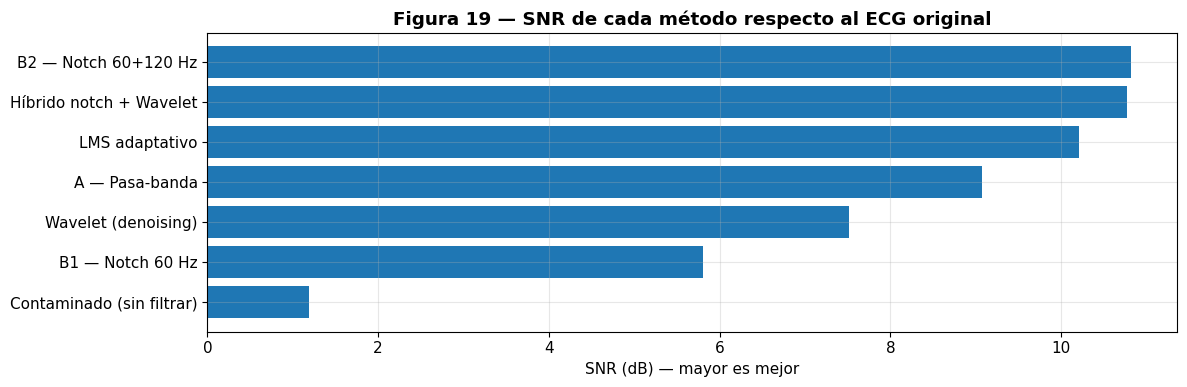

In [53]:
tabla_final = pd.DataFrame(resultados).T
tabla_final["Mejora SNR vs contaminado (dB)"] = tabla_final["SNR (dB)"] - tabla_final.loc["Contaminado (sin filtrar)", "SNR (dB)"]
display(tabla_final.round(4).sort_values("SNR (dB)", ascending=False))

# Gráfico de barras de SNR
plt.figure(figsize=(12, 4))
orden = tabla_final.sort_values("SNR (dB)")
plt.barh(orden.index, orden["SNR (dB)"], color="tab:blue")
plt.xlabel("SNR (dB) — mayor es mejor")
plt.title("Figura 19 — SNR de cada método respecto al ECG original")
plt.tight_layout(); plt.show()

### Comparación cualitativa

| Criterio | Pasa-banda | Notch | LMS adaptativo | Wavelet | Híbrido |
|---|---|---|---|---|---|
| Reducción de interferencias | **Alta** para 60/120 Hz al quedar fuera de la banda | **Alta y selectiva** en las frecuencias conocidas | **Alta** si existe una referencia correlacionada con la interferencia | **Baja–media** para senoides intensas; pueden sobrevivir al umbral | **Alta**: el notch elimina las interferencias |
| Reducción de ruido gaussiano | **Media**: elimina principalmente el ruido fuera de 0.5–40 Hz | **Baja**: el ruido de banda ancha permanece | **Baja**: el LMS no aprende ruido no correlacionado con la referencia | **Alta** para coeficientes pequeños de banda ancha | **Alta**: Wavelet reduce el ruido residual después del notch |
| Conservación de la morfología | **Media–alta**, pero puede redondear QRS y quitar deriva | **Alta**, porque elimina bandas muy estrechas | **Alta** después de la convergencia | **Media–alta**, con posible reducción de picos por `soft thresholding` | **Alta**, con ligero suavizado posible |
| Distorsión introducida | **Media** | **Baja** | **Baja** después de converger; depende de $\mu$ | **Media** y dependiente del umbral/wavelet | **Baja–media** |
| Complejidad | Baja | Baja | Media | Media | Media |
| ¿Qué necesita conocer? | Banda del ECG | Frecuencia exacta | Señal de referencia | Wavelet, niveles, umbral | Frecuencias de interferencia + parámetros Wavelet |

### 🔎 Análisis global de las métricas

La señal contaminada presentó una SNR de **1.19 dB** y una correlación de **0.7544**, evidenciando una degradación importante respecto del ECG original. El mejor resultado cuantitativo fue el método **híbrido notch + Wavelet**, con **RMSE = 0.0292 mV**, **SNR = 10.95 dB** y **correlación $r = 0.9652$**. Le siguieron el notch de 60+120 Hz (**10.39 dB**) y el LMS adaptativo (**10.22 dB**).

El resultado muestra que cada técnica resuelve un problema diferente. El notch y el LMS son muy eficaces frente a interferencias estructuradas de 60 y 120 Hz, mientras que Wavelet es más apropiada para reducir el ruido de banda ancha. Por ello, la combinación de notch + Wavelet obtuvo el mejor equilibrio entre **reducción de contaminación** y **conservación de la morfología**.

> ⚖️ **Ningún método es universalmente superior.** La elección depende del tipo de contaminación, de qué información fisiológica debe conservarse y de la aplicación (monitoreo, diagnóstico, detección de QRS, tiempo real…).


---
# 🟦 BLOQUE 7 — Retroalimentación, síntesis e infografía *(15 min)*

## 📝 Actividad de análisis

Responde de forma breve y justificada (2 – 4 líneas por pregunta).

**Pregunta 1.** ¿Por qué es importante conocer la frecuencia de muestreo de una señal biomédica?

✍️ **Respuesta:**  
La frecuencia de muestreo indica cuántas muestras se registran por segundo y permite construir correctamente el eje temporal mediante $t=n/F_s$. Además, determina la frecuencia máxima que puede representarse sin aliasing, de acuerdo con Nyquist, y es indispensable para diseñar filtros digitales con frecuencias de corte correctas.

**Pregunta 2.** ¿Qué diferencia existe entre ruido e interferencia?

✍️ **Respuesta:**  
El **ruido** suele ser una componente aleatoria y de banda ancha, como el ruido gaussiano, mientras que una **interferencia** posee una estructura u origen identificable, por ejemplo una componente sinusoidal de 60 Hz proveniente de la red eléctrica. Esta diferencia permite seleccionar estrategias de filtrado distintas.

**Pregunta 3.** ¿Por qué una interferencia sinusoidal puede observarse como un pico en el dominio de la frecuencia?

✍️ **Respuesta:**  
Una señal sinusoidal concentra su energía alrededor de una frecuencia determinada. Por ello, al calcular la FFT aparece como un pico estrecho en esa frecuencia; en este laboratorio se observaron picos en **60 Hz y 120 Hz** después de agregar las interferencias artificiales.

**Pregunta 4.** ¿Qué sucede cuando aplicamos un filtro demasiado agresivo a una señal ECG? *(Sugerencia: prueba `fc_alta = 15` en el Experimento A y observa el QRS.)*

✍️ **Respuesta:**  
Un filtro demasiado agresivo no solo elimina ruido, sino también componentes reales del ECG. Si se reduce `fc_alta` a 15 Hz se eliminan componentes rápidas importantes del QRS, por lo que los picos pueden disminuir de amplitud, ensancharse o verse más redondeados. La señal puede parecer visualmente más limpia, pero contener menor información fisiológica.

**Pregunta 5.** ¿Cuál es la principal diferencia conceptual entre un filtro convencional y un filtro adaptativo?

✍️ **Respuesta:**  
Un filtro convencional posee coeficientes **fijos** definidos previamente a partir de sus frecuencias de corte o rechazo. En cambio, un filtro adaptativo modifica sus coeficientes durante el procesamiento utilizando una señal de referencia y un criterio de error, por lo que puede seguir interferencias cuya amplitud o fase cambian con el tiempo.

**Pregunta 6.** ¿Para qué sirve la Transformada Wavelet?

✍️ **Respuesta:**  
La Transformada Wavelet permite descomponer una señal en diferentes **escalas o bandas de frecuencia conservando información temporal**. De esta manera se puede conocer no solo qué componentes frecuenciales existen, sino también aproximadamente cuándo aparecen eventos rápidos o lentos dentro de la señal.

**Pregunta 7.** ¿Por qué la Transformada Wavelet puede resultar útil para analizar señales biomédicas?

✍️ **Respuesta:**  
Las señales biomédicas son frecuentemente no estacionarias y contienen eventos localizados, como los complejos QRS. Wavelet permite estudiar simultáneamente tiempo y escala, separando detalles rápidos, tendencias lentas y ruido; además, puede utilizarse para *denoising* sin aplicar necesariamente un único corte fijo a toda la señal.

**Pregunta 8.** ¿Qué información podría perderse durante el proceso de filtrado?

✍️ **Respuesta:**  
Puede perderse parte de la amplitud, duración o forma de las ondas P, QRS y T si sus componentes frecuenciales coinciden con las bandas eliminadas. También puede retirarse deriva de baja frecuencia que sea relevante para ciertos análisis. Por ello, eliminar más ruido no siempre significa conservar mejor la información fisiológica.

**Pregunta 9.** Si conoces la frecuencia exacta de una interferencia, ¿qué tipo de filtro podrías utilizar?

✍️ **Respuesta:**  
Se puede utilizar un **filtro notch o rechazabanda estrecho** centrado en la frecuencia de la interferencia. Por ejemplo, para una interferencia de red de 60 Hz se diseña un notch en 60 Hz; si existe un armónico importante en 120 Hz, puede añadirse un segundo notch en esa frecuencia.

**Pregunta 10.** ¿Por qué no debemos evaluar un filtro únicamente observando visualmente la señal?

✍️ **Respuesta:**  
Una señal muy suavizada puede parecer limpia y, sin embargo, haber perdido morfología fisiológica. La evaluación debe combinar inspección visual con métricas como **RMSE, SNR y correlación**, además de comprobar que estructuras importantes como los complejos QRS se conserven. Las métricas tampoco deben interpretarse de manera aislada, sino junto con la morfología.


## 🧠 SUMARIZE — ¿Qué aprendimos?

Resume en pocas líneas:

```text
1. ¿Qué problema tenía la señal?
2. ¿Cómo contaminamos la señal?
3. ¿Qué filtro utilizamos?
4. ¿Qué resultado obtuvimos?
5. ¿Para qué sirve un filtro adaptativo?
6. ¿Para qué sirve Wavelet?
7. ¿Qué método utilizarías y por qué?
```

✍️ **Respuesta:**

1. **¿Qué problema tenía la señal?** El ECG real ya presentaba ruido y algunos artefactos propios de la adquisición; además, para evaluar los métodos de filtrado se agregó una contaminación artificial conocida.

2. **¿Cómo contaminamos la señal?** Se sumaron al ECG original dos interferencias sinusoidales de **60 Hz y 120 Hz** y ruido gaussiano con $\sigma \approx 0.031$ mV. Esto redujo la SNR hasta aproximadamente **1.19 dB**.

3. **¿Qué filtro utilizamos?** Se compararon un pasa-banda de **0.5–40 Hz**, filtros notch en **60 y 120 Hz**, un filtro adaptativo **LMS** con $\mu=0.005$, *denoising* Wavelet con **db4** y umbralización *soft*, y un método híbrido notch + Wavelet.

4. **¿Qué resultado obtuvimos?** Todos los métodos redujeron parte de la contaminación, pero con diferentes compromisos. El método híbrido obtuvo el mejor resultado global, con **SNR = 10.95 dB**, **RMSE = 0.0292 mV** y **correlación = 0.9652** respecto al ECG original.

5. **¿Para qué sirve un filtro adaptativo?** Sirve para estimar y cancelar una interferencia utilizando una señal de referencia. Sus coeficientes se actualizan durante el procesamiento, por lo que puede seguir cambios de amplitud o fase que un filtro fijo no podría seguir de la misma manera.

6. **¿Para qué sirve Wavelet?** Permite analizar la señal en tiempo y escala y separar componentes rápidas y lentas. En este laboratorio fue especialmente útil para reducir ruido de banda ancha mediante umbralización de coeficientes.

7. **¿Qué método utilizarías y por qué?** Para esta contaminación utilizaría el **método híbrido notch + Wavelet**, porque las interferencias de 60/120 Hz son conocidas y se eliminan selectivamente con notch, mientras que Wavelet reduce parte del ruido gaussiano residual. Esta elección corresponde a este escenario y no implica que sea siempre el mejor método para cualquier ECG.


## 🎨 Actividad final — Infografía científica

Elabora una infografía sencilla (Canva, PowerPoint, Google Slides o a mano y fotografiada) con estas secciones:

1. **Señal original** — ECG adquirido con BITalino/OpenSignals (Fs, duración, canal A2).
2. **Contaminación** — `ECG + interferencia 1 + interferencia 2 + ruido` (indica frecuencias y amplitudes usadas).
3. **Filtrado** — método(s) aplicado(s) y sus parámetros.
4. **Resultado** — comparación *Original / Contaminada / Filtrada* + una métrica (SNR o r).
5. **Conceptos clave** — una línea para cada uno: *Ruido, Interferencia, Filtro, Filtro adaptativo, Wavelet, Denoising*.
6. **Conclusión** — 3 a 5 líneas: ¿qué método recuperó mejor la señal y qué limitaciones observaste?

**Flujo que debe mostrar la infografía:**

```text
ECG REAL → CONTAMINACIÓN → ANÁLISIS → FILTRADO → FILTRO ADAPTATIVO → WAVELET → COMPARACIÓN → CONCLUSIONES
```

La siguiente celda genera una **figura base** con tus propios resultados que puedes insertar en la infografía.

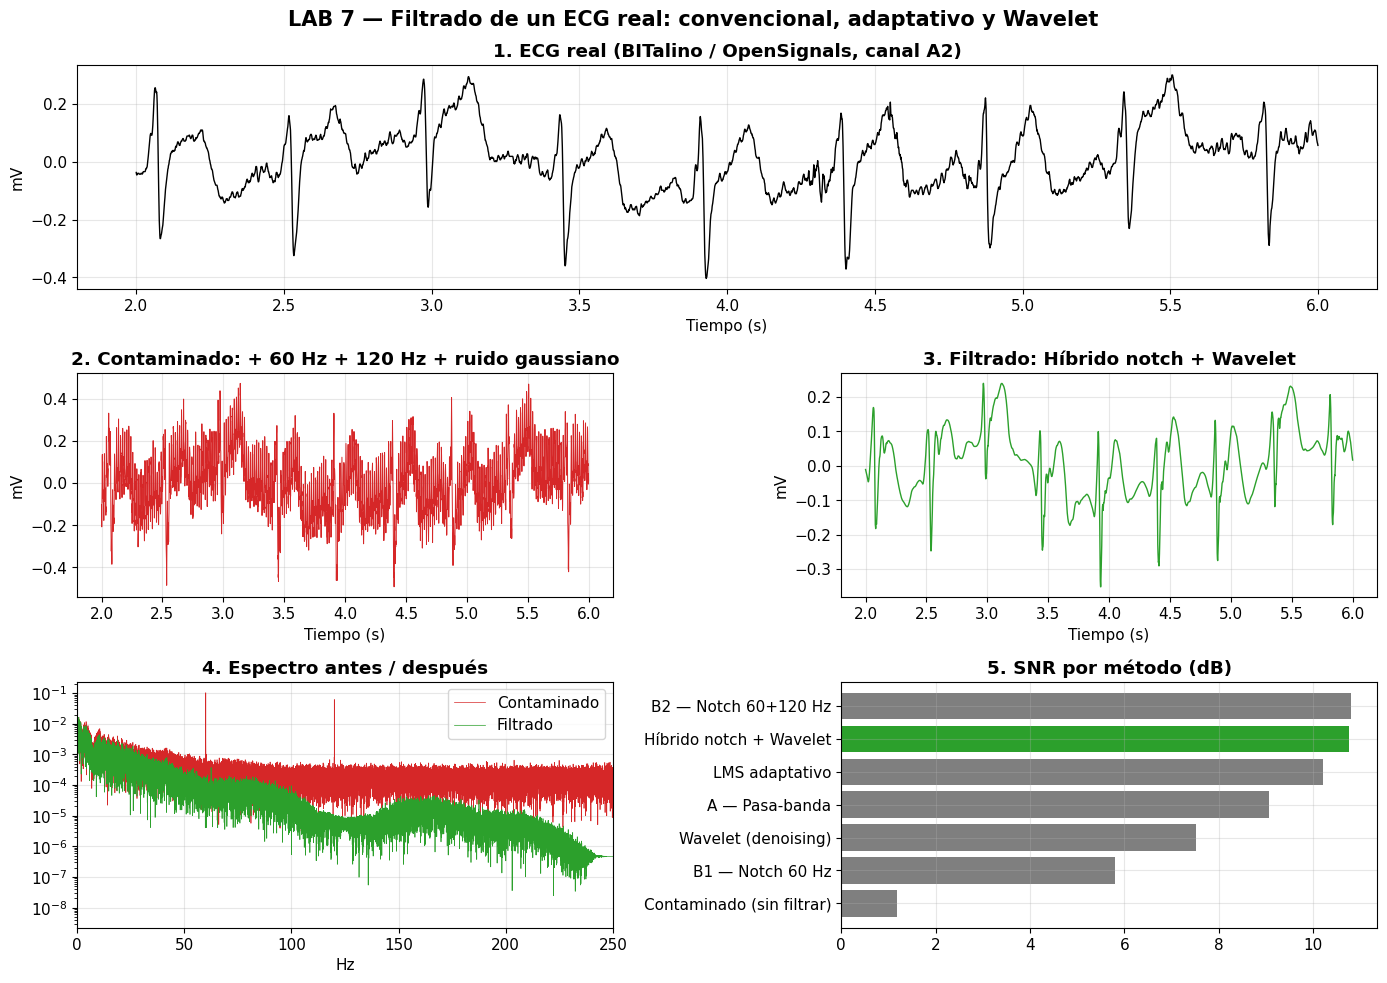

Figura guardada como 'figura_base_infografia.png'


In [54]:
# Elige el método que consideres mejor para la infografía (cambia la clave si lo deseas)
METODO_ELEGIDO = "Híbrido notch + Wavelet"
senales_metodos = {
    "A — Pasa-banda": ecg_pasabanda,
    f"B2 — Notch {f1}+{f2} Hz": ecg_notch_f1f2,
    "LMS adaptativo": ecg_lms,
    "Wavelet (denoising)": ecg_wavelet,
    "Híbrido notch + Wavelet": ecg_hibrido,
}
ecg_elegido = senales_metodos[METODO_ELEGIDO]

fig = plt.figure(figsize=(14, 10))
grid = fig.add_gridspec(3, 2, height_ratios=[1, 1, 1.1])

ax1 = fig.add_subplot(grid[0, :])
ax1.plot(t[zoom], ecg_original[zoom], color="black", lw=1)
ax1.set_title("1. ECG real (BITalino / OpenSignals, canal A2)")

ax2 = fig.add_subplot(grid[1, 0])
ax2.plot(t[zoom], ecg_contaminado[zoom], color="tab:red", lw=0.7)
ax2.set_title(f"2. Contaminado: + {f1} Hz + {f2} Hz + ruido gaussiano")

ax3 = fig.add_subplot(grid[1, 1])
ax3.plot(t[zoom], ecg_elegido[zoom], color="tab:green", lw=1)
ax3.set_title(f"3. Filtrado: {METODO_ELEGIDO}")

ax4 = fig.add_subplot(grid[2, 0])
ax4.semilogy(freq, amp_contaminado, color="tab:red", lw=0.5, label="Contaminado")
fr_e, am_e = espectro_amplitud(ecg_elegido, Fs)
ax4.semilogy(fr_e, am_e, color="tab:green", lw=0.5, label="Filtrado")
ax4.set_xlim(0, F_MAX_GRAFICO); ax4.legend(); ax4.set_xlabel("Hz")
ax4.set_title("4. Espectro antes / después")

ax5 = fig.add_subplot(grid[2, 1])
orden = tabla_final.sort_values("SNR (dB)")
colores = ["tab:green" if nombre == METODO_ELEGIDO else "tab:gray" for nombre in orden.index]
ax5.barh(orden.index, orden["SNR (dB)"], color=colores)
ax5.set_title("5. SNR por método (dB)")

for eje in (ax1, ax2, ax3):
    eje.set_xlabel("Tiempo (s)"); eje.set_ylabel("mV")
fig.suptitle("LAB 7 — Filtrado de un ECG real: convencional, adaptativo y Wavelet", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.savefig("figura_base_infografia.png", dpi=200, bbox_inches="tight")
plt.show()
print("Figura guardada como 'figura_base_infografia.png'")

## 🔁 Guía de retroalimentación para el docente (últimos 30 min)

| Momento | Actividad |
|---|---|
| min 90 – 95 | Cierre de la discusión Wavelet: ¿por qué sobrevivieron las interferencias al umbral? |
| min 95 – 105 | Revisar la tabla final y la Figura 19: comparar filtros; contrastar métricas con lo visual. |
| min 105 – 112 | Discutir errores frecuentes y revisar respuestas a las preguntas 1 – 10. |
| min 112 – 120 | Revisar avance de la síntesis e infografía; responder preguntas. |

**Errores frecuentes a discutir:**
- Graficar `nSeq` o las columnas digitales como si fueran ECG.
- Usar `nSeq` como eje de tiempo.
- Confundir ruido (aleatorio, banda ancha) con interferencia (estructurada, banda estrecha).
- Elegir un pasa-bajas con corte muy bajo y "aplanar" el QRS.
- Interpretar que una SNR alta garantiza una morfología clínicamente correcta.
- Olvidar que el LMS necesita un tiempo de convergencia.
- Asumir que la Wavelet elimina cualquier tipo de contaminación.

**Ideas clave para el cierre:**
- Filtro **convencional**: coeficientes fijos, efectivo si conocemos la banda del ruido.
- Filtro **adaptativo**: coeficientes que cambian, requiere una referencia, sigue interferencias variables.
- **Wavelet**: análisis tiempo-escala, útil para eventos localizados (QRS) y ruido de banda ancha.
- En la práctica se **combinan** técnicas según el problema.

## ✅ Conclusiones del laboratorio

✍️ Escribe tus conclusiones (5 – 8 líneas), considerando: reducción del ruido, conservación de la morfología, distorsión, complejidad y aplicación biomédica.

✍️ **Conclusiones:**

1. La contaminación artificial con interferencias de **60 Hz y 120 Hz** y ruido gaussiano permitió evaluar los filtros utilizando el ECG real original como referencia y comprobar cuantitativamente cuánto se recuperaba la señal.
2. Los filtros notch fueron muy eficaces para eliminar interferencias sinusoidales conocidas y conservaron mejor la morfología que un pasa-banda más amplio, mientras que el pasa-banda redujo ruido de alta frecuencia pero también modificó componentes reales del ECG.
3. El filtro adaptativo LMS alcanzó una **SNR de 10.22 dB** y una correlación de **0.9561**, mostrando que puede cancelar interferencias conocidas con poca alteración una vez que sus coeficientes convergen; su desempeño depende del paso $\mu$ y de disponer de una referencia adecuada.
4. El *denoising* Wavelet redujo el ruido de banda ancha, pero aplicado de forma aislada fue menos eficaz frente a las interferencias sinusoidales intensas, porque estas pueden generar coeficientes suficientemente grandes como para superar el umbral.
5. El enfoque **híbrido notch + Wavelet** produjo el mejor resultado de esta práctica, con **RMSE = 0.0292 mV, SNR = 10.95 dB y correlación $r = 0.9652$**, al combinar eliminación selectiva de interferencias con reducción del ruido residual.
6. Los resultados demuestran que un filtro no debe evaluarse únicamente por qué tan “limpia” se ve la señal: también es necesario comprobar que la morfología P–QRS–T se conserve y analizar métricas cuantitativas para identificar posibles distorsiones.
7. En aplicaciones biomédicas no existe un método universalmente superior; la estrategia de filtrado debe seleccionarse según el tipo de contaminación y la información fisiológica que se desea preservar.


---
# 📦 ENTREGA

### 1. Jupyter Notebook (`.ipynb`)
Debe contener:
- código ejecutado sin errores;
- todos los gráficos generados;
- respuestas a las preguntas de cada bloque y a las 10 preguntas de análisis;
- interpretación de resultados;
- sección *SUMARIZE* y conclusiones.

### 2. Infografía (PDF o PNG)
Debe sintetizar el flujo completo:

```text
ECG REAL
   ↓
CONTAMINACIÓN
   ↓
ANÁLISIS
   ↓
FILTRADO
   ↓
FILTRO ADAPTATIVO
   ↓
WAVELET
   ↓
COMPARACIÓN
   ↓
CONCLUSIONES
```

**Nombre de archivos sugerido:** `LAB7_Apellido_Nombre.ipynb` y `LAB7_Apellido_Nombre_infografia.pdf`

# 📊 Criterios de evaluación

| Criterio | Peso | Logrado (100%) | En proceso (50%) | No logrado (0%) |
|---|---:|---|---|---|
| Carga y comprensión de datos | 15% | Lee cabecera, identifica A2, construye `t` correctamente y justifica no usar `nSeq`. | Carga los datos con errores menores de interpretación. | No identifica el canal ECG o usa un eje temporal incorrecto. |
| Contaminación artificial | 15% | Genera y visualiza ambas interferencias y el ruido; interpreta el espectro. | Genera la contaminación pero la interpretación es incompleta. | No genera la contaminación o no la analiza. |
| Aplicación de filtros | 20% | Aplica pasa-banda y notch, muestra respuestas en frecuencia y explica efectos. | Aplica los filtros sin justificar parámetros. | No aplica los filtros correctamente. |
| Análisis e interpretación | 20% | Integra métricas y observación visual; reconoce distorsiones y limitaciones. | Interpretación superficial o solo visual. | Sin interpretación. |
| Filtro adaptativo y Wavelet | 15% | Explica el LMS (referencia, error, coeficientes) y el denoising Wavelet; experimenta con parámetros. | Ejecuta el código sin explicar los conceptos. | No aborda estos métodos. |
| Infografía y comunicación | 15% | Infografía clara, completa (6 secciones) y con conclusión fundamentada. | Infografía incompleta o poco clara. | No entrega infografía. |
| **Total** | **100%** | | | |